In [1]:
import warnings
warnings.filterwarnings('ignore')

try:
    from databook_utils.dandi_utils import dandi_download_open
except:
    !git clone https://github.com/AllenInstitute/openscope_databook.git
    %cd openscope_databook
    %pip install -e .

In [2]:
%pip install numpy pandas scipy matplotlib Pillow
import os
import numpy as np            # various numerical utilities
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image
from math import floor, ceil

Note: you may need to restart the kernel to use updated packages.


In [3]:
import warnings
warnings.filterwarnings('ignore')

try:
    from databook_utils.dandi_utils import dandi_stream_open
except:
    !git clone https://github.com/AllenInstitute/openscope_databook.git
    %cd openscope_databook
    %pip install -e .

In [4]:
%pip install h5py pynwb remfile dandi 
import os

import h5py
import pandas as pd
import remfile

from dandi import dandiapi
from pynwb import NWBHDF5IO

%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [5]:
dandiset_id = "000563"
dandi_filepath = "sub-681446/sub-681446_ses-1290510496_ogen.nwb"
download_loc = "."
dandi_api_key = None

In [6]:
my_dandiset = dandiapi.DandiAPIClient(token=dandi_api_key).get_dandiset(dandiset_id)
print(f"Got dandiset {my_dandiset}")

Got dandiset DANDI:000563/0.250311.2145


In [7]:
nwb_type = "ephys" # or, "ophys"

In [8]:
# get experimental information from within ecephys file
# getattr is used because not all nwb files have all properties. If not handled like this, errors will arise
def get_ephys_nwb_info(nwb):
        session_time = getattr(nwb, "session_start_time", None)

        subject = getattr(nwb, "subject", None)
        specimen_name = getattr(subject, "specimen_name", None)
        age = getattr(subject, "age_in_days", None)
        sex = getattr(subject, "sex", None)
        genotype = getattr(subject, "genotype", None)

        probes = set(getattr(nwb, "devices", {}).keys())
        units = getattr(nwb, "units", [])
        n_units = len(units) if hasattr(units, '__len__') else 0        
        
        intervals = getattr(nwb, "intervals", {})
        stim_types = set(intervals.keys())
        stim_tables = [intervals[table_name] for table_name in intervals]
        # gets highest value among final "stop times" of all stim tables in intervals
        session_end = max([table.stop_time[-1] for table in stim_tables if len(table) > 1])

        return [session_time, specimen_name, sex, age, genotype, probes, stim_types, n_units, session_end]

In [9]:
nwb_table = []
# skip files that aren't main session files
files = [asset for asset in my_dandiset.get_assets() if "probe" not in asset.path]
# swap this with line above for one of our ophys dandisets
# files = [asset for asset in my_dandiset.get_assets() if "raw" not in asset.path]
n_files = len(files)
print(f"{n_files} files retrieved")

extract_nwb_info = get_ephys_nwb_info if nwb_type == "ephys" else get_ophys_nwb_info

for i, file in enumerate(files):
    print(f"Examining file {i+1}/{n_files}: {file.identifier}")    
    # get basic file metadata
    row = [file.identifier, file.size, file.path]
    
    base_url = file.client.session.head(file.base_download_url)
    file_url = base_url.headers["Location"]

    # open and read nwb file with streaming
    rem_file = remfile.File(file_url)
    h5py_file = h5py.File(rem_file, "r")
    io = NWBHDF5IO(file=h5py_file, mode="r", load_namespaces=True)
    nwb = io.read()

    # extract experimental info from within file
    row += extract_nwb_info(nwb)
    nwb_table.append(row)
    del nwb

    # don't run full loop if running in test environment
    if os.environ.get("TESTING", False):
        break

14 files retrieved
Examining file 1/14: c3bbf094-904e-43b7-83d5-be5a8bf3826f
Examining file 2/14: ad5f1431-2119-4e85-b98e-0a89d5c6fd08
Examining file 3/14: 26c15f00-af2c-4cc3-97a2-ab32dbe998ae
Examining file 4/14: 9f6591b5-22b5-4a23-8009-d9cfba9fe525
Examining file 5/14: cbc9402d-64ff-4a8f-a688-add16d7b984c
Examining file 6/14: ae100c59-59ce-4f46-b4be-0d68ea357372
Examining file 7/14: e367b37d-c854-45ba-bdae-602df4614dea
Examining file 8/14: 0e172dc4-eeb4-408d-946f-c80d83cce34a
Examining file 9/14: 518fffd6-6ad2-4021-89eb-c0bb1767d541
Examining file 10/14: 96786f67-a6ac-44dc-ba58-61317082fff3
Examining file 11/14: 74d2c6b9-8bbf-4ff1-b2a2-b91d401c12bb
Examining file 12/14: 2f2ac304-83a3-4352-8612-5f34b68062a0
Examining file 13/14: fb92563d-0e56-4c61-aa86-5645a637fa2d
Examining file 14/14: 9bdb7302-dce6-4da7-b8b3-10b4bf9c998c


In [10]:
# convert table to pandas dataframe
if nwb_type == "ephys":
    dandiset_files = pd.DataFrame(nwb_table, columns=("identifier", "size", "path", "session_time", "sub_name", "sub_sex", "sub_age", "sub_genotype", "probes", "stim types", "#_units", "session_length"))
else:
    dandiset_files = pd.DataFrame(nwb_table, columns=("identifier", "size", "path", "session_time", "sub_name", "session_id", "experiment_id", "container_id", "group", "group_count", "imaging_depth", "location", "fov_height", "fov_width", "specimen_name", "sub_sex", "sub_age", "sub_genotype", "stim_types", "#_rois", "session_end"))
dandiset_files

,identifier,size,path,session_time,sub_name,sub_sex,sub_age,sub_genotype,probes,stim types,#_units,session_length
0,c3bbf094-904e-43b7-83d5-be5a8bf3826f,2828829044,sub-699241/sub-699241_ses-1318772854_ogen.nwb,2023-12-19 00:00:00-08:00,699241,M,124.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",2299,7251.236727
1,ad5f1431-2119-4e85-b98e-0a89d5c6fd08,2992502541,sub-699846/sub-699846_ses-1314466742_ogen.nwb,2023-11-30 00:00:00-08:00,699846,M,100.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",2771,7248.796817
2,26c15f00-af2c-4cc3-97a2-ab32dbe998ae,4721689639,sub-698259/sub-698259_ses-1314229564_ogen.nwb,2023-11-29 00:00:00-08:00,698259,M,111.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",2744,12104.177757
3,9f6591b5-22b5-4a23-8009-d9cfba9fe525,3058306362,sub-692990/sub-692990_ses-1310924284_ogen.nwb,2023-11-14 00:00:00-08:00,692990,F,129.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",3338,7248.085747
4,cbc9402d-64ff-4a8f-a688-add16d7b984c,2973901434,sub-697302/sub-697302_ses-1309845146_ogen.nwb,2023-11-09 00:00:00-08:00,697302,F,97.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",2824,7248.555437
5,ae100c59-59ce-4f46-b4be-0d68ea357372,3077972048,sub-697303/sub-697303_ses-1309536438_ogen.nwb,2023-11-08 00:00:00-08:00,697303,F,96.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",3465,7254.287277
6,e367b37d-c854-45ba-bdae-602df4614dea,3157021325,sub-692360/sub-692360_ses-1301730660_ogen.nwb,2023-10-05 00:00:00-07:00,692360,M,94.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",2844,7250.575147
7,0e172dc4-eeb4-408d-946f-c80d83cce34a,2739385785,sub-692991/sub-692991_ses-1308221984_ogen.nwb,2023-11-02 00:00:00-07:00,692991,F,117.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",2529,7248.935487
8,518fffd6-6ad2-4021-89eb-c0bb1767d541,2978882451,sub-692984/sub-692984_ses-1303229472_ogen.nwb,2023-10-12 00:00:00-07:00,692984,M,96.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",2892,7249.644247
9,96786f67-a6ac-44dc-ba58-61317082fff3,2555712145,sub-685263/sub-685263_ses-1292234897_ogen.nwb,2023-08-23 00:00:00-07:00,685263,M,95.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",2791,7248.094377


In [11]:
if nwb_type == "ephys":
    m_count = len(dandiset_files["sub_sex"][dandiset_files["sub_sex"] == "M"])
    f_count = len(dandiset_files["sub_sex"][dandiset_files["sub_sex"] == "F"])
    sst_count = len(dandiset_files[dandiset_files["sub_genotype"].str.count("Sst") >= 1])
    pval_count = len(dandiset_files[dandiset_files["sub_genotype"].str.count("Pval") >= 1])
    wt_count = len(dandiset_files[dandiset_files["sub_genotype"].str.count("wt/wt") >= 1])
    print("Dandiset Overview:")
    print(len(dandiset_files), "dandiset_files")
    print(len(set(dandiset_files["sub_name"])), "subjects", m_count, "males,", f_count, "females")
    print(sst_count, "sst,", pval_count, "pval,", wt_count, "wt")
else:
    n_sessions = len(dandiset_files["session_id"].value_counts())
    subjects_info = dandiset_files.groupby(["sub_name", "sub_sex"]).size().reset_index().to_dict()
    m_count = len([sex for sex in subjects_info["sub_sex"].values() if sex == "M"])
    f_count = len([sex for sex in subjects_info["sub_sex"].values() if sex == "F"])
    print("Dandiset Overview:")
    print(len(dandiset_files), "dandiset_files")
    print(len(subjects_info["sub_name"]), "subjects", m_count, "males", f_count,"females")

Dandiset Overview:
14 dandiset_files
14 subjects 9 males, 5 females
8 sst, 6 pval, 0 wt


In [12]:
# output all session metadata to local CSV file
dandiset_files.to_csv("dandiset_files.csv")

In [13]:
selected_files = dandiset_files[dandiset_files["size"] <= 2_628_829_044]

selected_files

,identifier,size,path,session_time,sub_name,sub_sex,sub_age,sub_genotype,probes,stim types,#_units,session_length
9,96786f67-a6ac-44dc-ba58-61317082fff3,2555712145,sub-685263/sub-685263_ses-1292234897_ogen.nwb,2023-08-23 00:00:00-07:00,685263,M,95.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",2791,7248.094377
11,2f2ac304-83a3-4352-8612-5f34b68062a0,2504326547,sub-681446/sub-681446_ses-1290510496_ogen.nwb,2023-08-16 00:00:00-07:00,681446,M,112.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{probeA, probeF, OptogeneticStimulusDevice, pr...","{invalid_times, RepeatFFF_presentations, Uniqu...",2572,7249.424087


In [14]:
download_loc = "."

In [15]:
selected_paths = set(selected_files.path)
selected_paths

{'sub-681446/sub-681446_ses-1290510496_ogen.nwb',
 'sub-685263/sub-685263_ses-1292234897_ogen.nwb'}

In [16]:
#for dandi_filepath in selected_paths:
#    filename = dandi_filepath.split("/")[-1]
#    file = my_dandiset.get_asset_by_path(dandi_filepath)
#    file.download(f"{download_loc}/{filename}")
#    print(f"Downloaded file to {download_loc}/{filename}")

In [17]:
session_files = pd.read_csv(r"C:\Users\gamei\Downloads\NeurSysProject\openscope_databook\dandiset_files.csv")
session_files

m_count = len(session_files["sub_sex"][session_files["sub_sex"] == "M"])
f_count = len(session_files["sub_sex"][session_files["sub_sex"] == "F"])
sst_count = len(session_files[session_files["sub_genotype"].str.count("Sst") >= 1])
pval_count = len(session_files[session_files["sub_genotype"].str.count("Pval") >= 1])
wt_count = len(session_files[session_files["sub_genotype"].str.count("wt/wt") >= 1])

print("Dandiset Overview:")
print(len(session_files), "files")
print(len(set(session_files["sub_name"])), "subjects", m_count, "males,", f_count, "females")
print(sst_count, "sst,", pval_count, "pval,", wt_count, "wt")

Dandiset Overview:
14 files
14 subjects 9 males, 5 females
8 sst, 6 pval, 0 wt


In [18]:
# This can sometimes take a while depending on the size of the file
io = dandi_download_open(dandiset_id, dandi_filepath, download_loc, dandi_api_key=dandi_api_key)
nwb = io.read()

File already exists
Opening file


In [19]:
try:
    from databook_utils.dandi_utils import dandi_download_open
except:
    !git clone https://github.com/AllenInstitute/openscope_databook.git
    %cd openscope_databook
    %pip install -e .

In [20]:
%pip install ccfwidget itkwidgets
import numpy as np

from ccfwidget import CCFWidget

# required because CCFwidgets is not using latest version of collections.abc
import collections
import collections.abc
collections.Sequence = collections.abc.Sequence

In [21]:
dandiset_id = "000563"
dandi_filepath = "sub-681446/sub-681446_ses-1290510496_ogen.nwb"
download_loc = "."

In [22]:
# This can sometimes take a while depending on the size of the file
io = dandi_download_open(dandiset_id, dandi_filepath, download_loc)
nwb = io.read()

File already exists
Opening file


In [23]:
### read the x,y,z ccf coordinates and generate points
xs = nwb.electrodes.x
ys = nwb.electrodes.y
zs = nwb.electrodes.z
n = min(len(xs), len(ys), len(zs))
points = np.array([[xs[i], ys[i], zs[i]] for i in range(n)])

In [24]:
# each point has 3 coordinates associated with it
print(points.shape)

(2304, 3)


In [25]:
# the 'markers' parameter will expect an iterable where each point is represented as [x,y,z]ccf = CCFWidget(markers=[points])

In [26]:
# Helper function to find the brain location of each unit
def getUnitsLocation(nwb):
    """
   
    INPUTS:
      nwb      an nwb object
    OUTPUTS:
      unit_locations  List of the assigned brain locations of all units in the units table
    """
    units=nwb.units
    units_peak_channel_id = list(units.peak_channel_id)
    n_units=len(units_peak_channel_id)
    electrodes = nwb.electrodes  
    channelLocations=list(electrodes.location) # anatomic locations of each channel
    channelIDs =list(electrodes.id)  # the id for that channel
    unit_locations=np.zeros((n_units,)).astype(str)
    for i in range(n_units):
        #find the brain region closest to the channel which has the peak value for that unit
        unit_locations[i]=channelLocations[channelIDs.index(units_peak_channel_id[i])] 
    return unit_locations

In [27]:
# Load the unit information needed for the anlaysis
units = nwb.units          # extract spike times from the Units Data table 
units_spike_times = units["spike_times"] # pull out the `spike_times` attribute to be used later
n_units = len(units_spike_times)
print('Number of units: ',n_units)

# example of unit properties one might use to filter the units
units_quality = list(units["quality"]) # quality metric of each unit - list of strings
units_isiviol = list(units["isi_violations"]) # isi violation metric or each unit - list of floats

# make a list with indexes of selected units
goodUnits=[]
for i in range(len(units_quality)):
    if units_quality[i]=='good' and units_isiviol[i]<1:
        goodUnits.append(i)
        
print('of which ', len(goodUnits), 'qualify for inclusion')

#retrieve the anatomical locations assigned to the units
units_location = getUnitsLocation(nwb)
print('The selected units were found in: ')
np.unique(units_location[goodUnits])

Number of units:  2572
of which  1511 qualify for inclusion
The selected units were found in: 


array(['APN', 'CA1', 'CA2', 'CA3', 'DG-mo', 'DG-po', 'DG-sg', 'HPF',
       'LGd-co', 'LGd-ip', 'LGd-sh', 'LP', 'MB', 'MRN', 'POST', 'SCig',
       'SSp-bfd4', 'SSp-bfd5', 'SSp-bfd6a', 'TH', 'VISal1', 'VISal2/3',
       'VISal4', 'VISal5', 'VISal6a', 'VISam2/3', 'VISam4', 'VISam5',
       'VISam6a', 'VISam6b', 'VISl4', 'VISl5', 'VISl6a', 'VISl6b',
       'VISp2/3', 'VISp4', 'VISp5', 'VISp6a', 'VISpm2/3', 'VISpm4',
       'VISpm5', 'VISpm6a', 'root'], dtype='<U32')

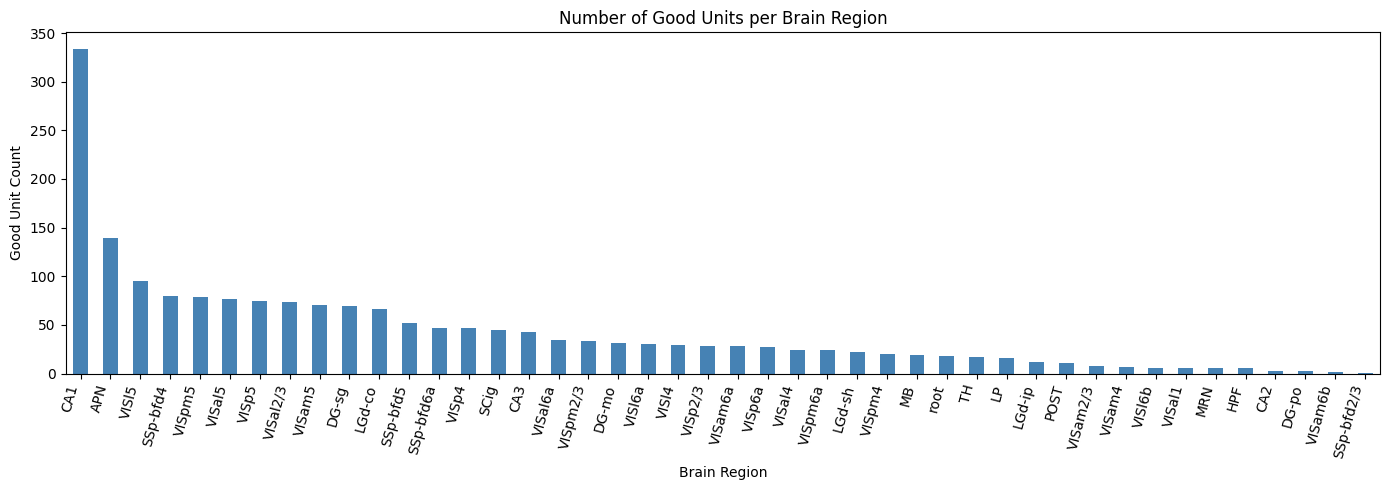

,sub_genotype,n_sessions,total_units,mean_units_per_session
0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,8,23723,2965.375
1,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,6,15657,2609.500


In [28]:
# Bar chart: number of good units per brain region
good_mask = np.array(units_quality) == "good"
good_units_by_region = (
    pd.Series(units_location[good_mask], name="brain_region")
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 5))
good_units_by_region.plot(kind="bar", color="steelblue")
plt.title("Number of Good Units per Brain Region")
plt.xlabel("Brain Region")
plt.ylabel("Good Unit Count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

# Table: number of units per genotype
source_df = session_files if "session_files" in globals() else dandiset_files
units_per_genotype = (
    source_df.groupby("sub_genotype", dropna=False)["#_units"]
    .agg(n_sessions="count", total_units="sum", mean_units_per_session="mean")
    .sort_values("total_units", ascending=False)
    .reset_index()
)

units_per_genotype

In [29]:
# Find out what stimulus conditions were used in the experiment
# See bottom of this notebook for more about the timeline of the entire experiment
StimulusTypes=list(nwb.intervals.keys())
StimulusTypes

['RepeatFFF_presentations',
 'UniqueFFF_presentations',
 'invalid_times',
 'receptive_field_block_presentations',
 'static_block_presentations']

In [30]:
# The full field flicker stimulus was sufficient to observe a barcode in all units that had barcodes,
# and is the easiest to interpret because all neurons had the identical stimulus in their receptive fields 
stimTypeToExtract='RepeatFFF_presentations'
# Information about the stimulus
stim_table = nwb.intervals[stimTypeToExtract]    
stim_table

,start_time,stop_time,stimulus_name,stimulus_block,index_repeat,contrast,mask,opacity,orientation,phase,spatial_frequency,size,units,stimulus_index,color,tags,timeseries
id,,,,,,,,,,,,,,,,,
0,163.46116,163.47784,RepeatFFF,1.0,0.0,1.0,None,1.0,0.0,"[0.0, 0.0]","[0.0, 0.0]","[250.0, 250.0]",deg,1.0,1.0,[stimulus_time_interval],"[(7200, 1, timestamps pynwb.base.TimeSeries at 0x2146561344272\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (405120,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (405120,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
1,163.47784,163.49453,RepeatFFF,1.0,0.0,1.0,None,1.0,0.0,"[0.0, 0.0]","[0.0, 0.0]","[250.0, 250.0]",deg,1.0,1.0,[stimulus_time_interval],"[(7201, 1, timestamps pynwb.base.TimeSeries at 0x2146561344272\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (405120,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (405120,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
2,163.49453,163.51118,RepeatFFF,1.0,0.0,1.0,None,1.0,0.0,"[0.0, 0.0]","[0.0, 0.0]","[250.0, 250.0]",deg,1.0,-1.0,[stimulus_time_interval],"[(7202, 1, timestamps pynwb.base.TimeSeries at 0x2146561344272\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (405120,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (405120,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
3,163.51118,163.52780,RepeatFFF,1.0,0.0,1.0,None,1.0,0.0,"[0.0, 0.0]","[0.0, 0.0]","[250.0, 250.0]",deg,1.0,-1.0,[stimulus_time_interval],"[(7203, 1, timestamps pynwb.base.TimeSeries at 0x2146561344272\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (405120,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (405120,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"


In [31]:
# pull out some stimulus details we will need for our analysis
StimIndexList=np.unique(np.array((stim_table["stimulus_index"])) )  # array of stimulus conditions 
IndexRepeatList=np.unique(np.array((stim_table["index_repeat"]))) # array of repeat numbers within the block 
StimNameList=set(stim_table["stimulus_name"])
nPresentations=len(StimIndexList); # determine number of instances from the data
# determine nRepeats from the data
nRepeats=len(IndexRepeatList)
print(stimTypeToExtract,' was repeated ',nRepeats,' times')

RepeatFFF_presentations  was repeated  90  times


In [32]:
# Find the start times of the repeated stimulus
# cast the index_repeat and stim_index columns from  hdmf.common.table.VectorData into arrays
index_repeat=np.array(stim_table["index_repeat"])  
stim_index=np.array(stim_table["stimulus_index"])
# note that the repeats are not necessarily back to back so the duration is determined by 
# the end time of the same repeat, not the start time of the next repeat
stim_times=np.zeros(nRepeats*nPresentations)
endtime=np.zeros(nRepeats*nPresentations)
for k in range(nPresentations): #loop over presentations of this stimulus
    mask1=stim_index==StimIndexList[k] #true for all elements in this presentation
    for j in range(nRepeats):   #loop over repeats within the presentation
        mask2=index_repeat==j #true for all elements with this repeat number
        ind1=np.where(np.logical_and(mask1,mask2))[0][0] # index of first element meeting conditions
        stim_times[k*nRepeats+j]= stim_table["start_time"][ind1]

        ind2=np.where(np.logical_and(mask1,mask2))[0][-1]  # index of last element meeting conditions
        endtime[k*nRepeats+j]= stim_table["stop_time"][ind2]

# the actual duration of each repeat is given by end_time-start_time
# average these to get the nominal duration for all trials, for further analysis
eachduration=endtime-stim_times # the values should be close to identical (check this)
trial_duration=np.mean(eachduration) # then set the "duration" variable to the mean duration 
trial_duration=np.round(trial_duration*1000)/1000  #truncated to three significant digits

totalStimTime=trial_duration*nRepeats # time in seconds total over all repeats

In [33]:
#  makeAlignedEvents:  a helper function that extracts and aligns spike times for one unit
def makeAlignedEvents(spike_times,stim_times,duration:float):
    """
    INPUTS:
    spike_times     array of spike times of a single unit, in seconds
    stim_times      array of start times of a repeated stimulus, in seconds
    duration        duration of the repeated stimulus, in seconds
    
    OUTPUTS:
    events          1D array whose elements are all times when a spike is seen in a repeat relative to the start of repeat
  
    """
    nRepeats=len(stim_times) #number of stim_time entries would give us the number of repeats for that stimulus
    events=np.zeros((nRepeats,)).tolist()
    
    for stim_idx, stim_time in enumerate(stim_times): 
        first_spike_in_range, last_spike_in_range = np.searchsorted(spike_times, [stim_time, stim_time+duration])
        spike_times_in_range = np.array(spike_times[first_spike_in_range:last_spike_in_range])  
        spike_times_in_range=spike_times_in_range-stim_time #set trial start as time 0 
        events[stim_idx]=spike_times_in_range.tolist()

    return events

In [34]:
# Choose example units to illustrate the barcode analysis methods
# These examples were chosen to illustrate two different barcodes and a neuron without a barcode
# in the sections below
example_indices = goodUnits

# Extract the aligned spike times of the example neurons
rasters=[] # the aligned spike times
FR =[]     # firing rate  
for i in range(len(example_indices)):
    rasters.append( makeAlignedEvents(units_spike_times[example_indices[i]],stim_times,trial_duration) )
    # count spikes in all the repeats to estimate the firing rate
    nspk=0 
    for j in range(nRepeats):
        nspk += len(rasters[i][j])
    FR.append(nspk/totalStimTime) 
    # print summary information about the examples
    print('example', i+1, 'is unit',example_indices[i],', recorded from ', units_location[example_indices[i]], ', FR=',np.round(FR[i],1),' spk/sec')

example 1 is unit 0 , recorded from  APN , FR= 0.6  spk/sec
example 2 is unit 1 , recorded from  APN , FR= 46.0  spk/sec
example 3 is unit 2 , recorded from  APN , FR= 0.4  spk/sec
example 4 is unit 3 , recorded from  APN , FR= 8.3  spk/sec
example 5 is unit 4 , recorded from  APN , FR= 10.0  spk/sec
example 6 is unit 5 , recorded from  APN , FR= 12.2  spk/sec
example 7 is unit 6 , recorded from  APN , FR= 17.8  spk/sec
example 8 is unit 7 , recorded from  APN , FR= 15.5  spk/sec
example 9 is unit 8 , recorded from  APN , FR= 0.3  spk/sec
example 10 is unit 9 , recorded from  APN , FR= 0.8  spk/sec
example 11 is unit 10 , recorded from  APN , FR= 41.2  spk/sec
example 12 is unit 11 , recorded from  APN , FR= 0.6  spk/sec
example 13 is unit 13 , recorded from  APN , FR= 26.0  spk/sec
example 14 is unit 15 , recorded from  APN , FR= 1.2  spk/sec
example 15 is unit 16 , recorded from  APN , FR= 9.5  spk/sec
example 16 is unit 17 , recorded from  APN , FR= 5.7  spk/sec
example 17 is unit 1

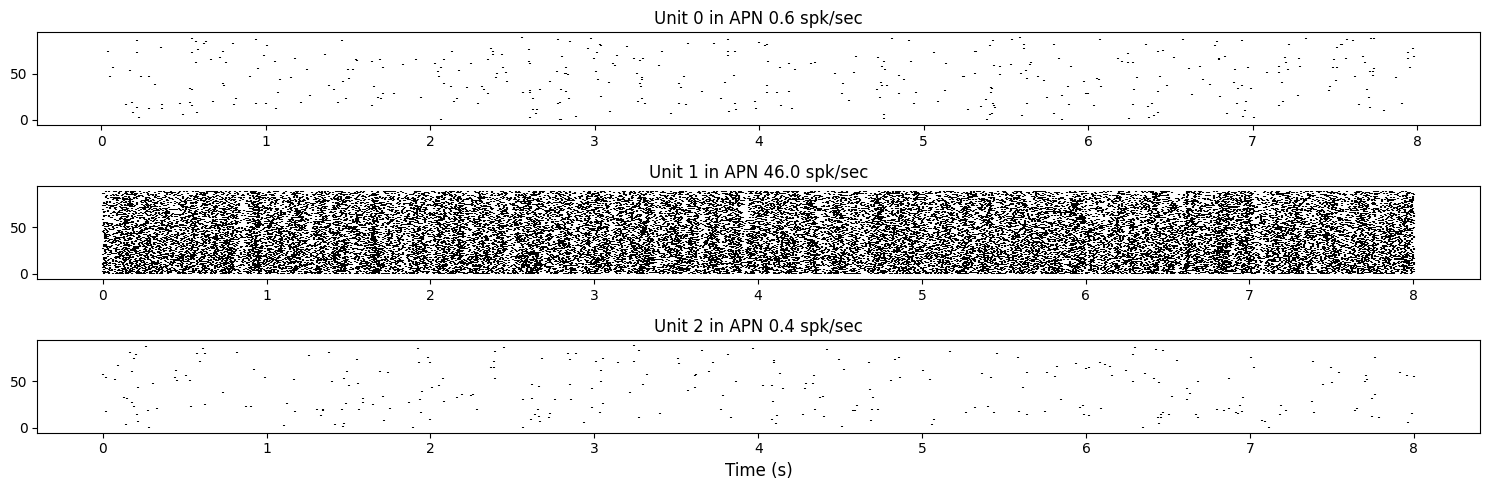

In [35]:
#show rasters for three example cells
fig, axes = plt.subplots(3, 1, figsize=(15, 5))  # 1 row, 3 columns
for i in range(3):
    axes[i].eventplot(rasters[i], colors='black')
    title = "Unit %d in %s %.1f spk/sec" % (example_indices[i], units_location[example_indices[i]],FR[i])
    axes[i].set_title(title)

plt.xlabel("Time (s)", fontsize=12) 
plt.tight_layout()
plt.show()

In [36]:
# compute_psth: helper function to compute PSTH by assigning spike times to time bins
def compute_psth(spike_trains, total_duration, bin_duration):
    n_bins = int(total_duration / bin_duration)
    psth = np.zeros(n_bins, dtype=float)
    for train in spike_trains:
        binned_spikes = np.floor(np.array(train) / bin_duration).astype(int)
        valid_bins = binned_spikes[binned_spikes < n_bins]
        psth[valid_bins] += 1
    psth /= len(spike_trains)
    return psth 

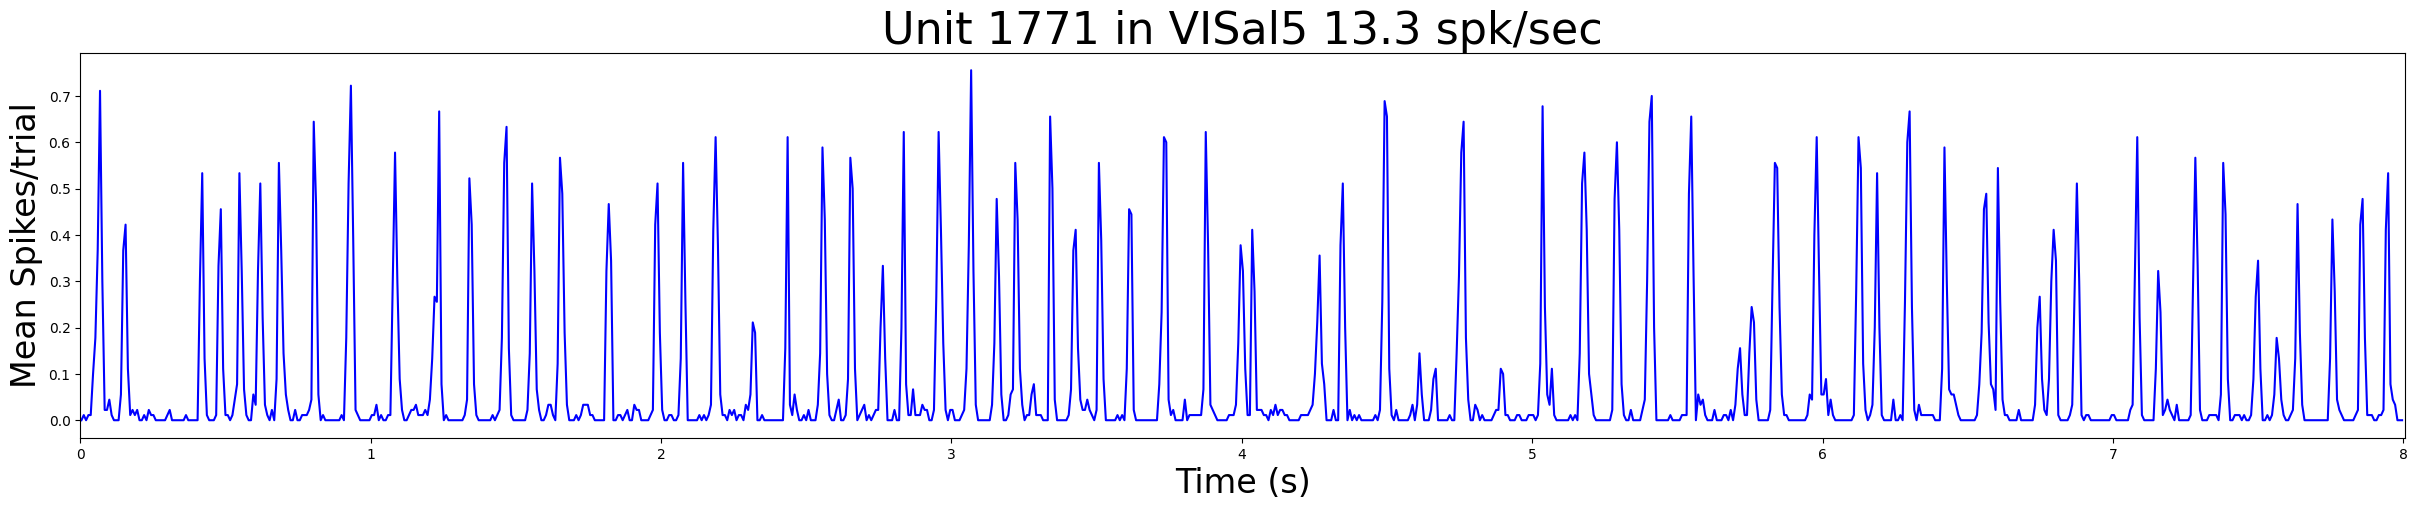

In [37]:
# Plot the psth of one of the example neurons 
example=1042  # first example neuron
bin_duration = 0.008 # Time bin to use in seconds 
psth1=compute_psth(rasters[example], trial_duration, bin_duration)
n_bins = len(psth1)
bin_midpoints = (np.arange(n_bins) + 0.5) * bin_duration
fig, ax = plt.subplots(figsize=(30, 5))
plt.plot(bin_midpoints, psth1, color='blue')
plt.xlabel('Time (s)',fontsize=24)
plt.ylabel('Mean Spikes/trial',fontsize=24)
title = "Unit %d in %s %.1f spk/sec" % (example_indices[example], units_location[example_indices[example]],FR[example])
plt.title(title,fontsize=32)
plt.xlim([0,trial_duration])
plt.show()

In [38]:
# getSpikeCountThreshold: helper function to determine the number of spikes in psth bin expected by chance
def getSpikeCountThreshold(rate, M, N, alpha, doplot=False):
    """
    Returns criterion spike-count thresholds (high and low) for detecting
    significantly above- or below-chance spike counts in any one time bin
    of a raster, under a Poisson null hypothesis.

    Parameters
    ----------
    rate : float
        Mean spikes per bin in the data raster overall
    M : int
        Number of trials in the data raster
    N : int
        Number of time bins in the data raster
    alpha : float
        Acceptable fraction of false positives (e.g., 0.05)
    doplot : bool, optional
        If True, plot the PDF and thresholds (default False)

    Returns
    -------
    highThresh : int
        Minimum spike count significantly above chance (Bonferroni-corrected)
    lowThresh : int
        Maximum spike count significantly below chance, or -1 if none
    """
    # Bonferroni correction for multiple comparisons
    adj_alpha = alpha / N
    
    # Find low threshold
    Clow = 0
    while poisson.pmf(Clow, rate * M) < adj_alpha:
        Clow += 1
    lowThresh = Clow - 1  # If Clow never increments, this becomes -1

    # Find high threshold, starting from Clow
    Chigh = Clow
    while poisson.pmf(Chigh, rate * M) > adj_alpha:
        Chigh += 1
    highThresh = Chigh

    # Optional plotting
    if doplot:
        C = np.arange(0, Chigh + 1)
        P = poisson.pmf(C, rate * M)
        plt.figure()
        plt.semilogy(C, P, 'o-')
        plt.xlabel(f'Spike count over M={M} trials')
        plt.ylabel('Probability on Poisson Null')
        plt.title(f'For Mean {rate:.3f} spikes/bin, N={N} timebins')
        plt.axhline(y=adj_alpha, color='r', linestyle='-')
        plt.text(Chigh, adj_alpha, f' α={alpha:.2f}', color='r')
        plt.text(Chigh / 2, 3 * adj_alpha, 'nonsignificant',
                 ha='center', color='r')
        plt.text(Chigh / 2, adj_alpha / 3, 'significant',
                 ha='center', color='r')
        plt.xticks() # to be coded: force xticks to be integers
        plt.show()

    return highThresh, lowThresh

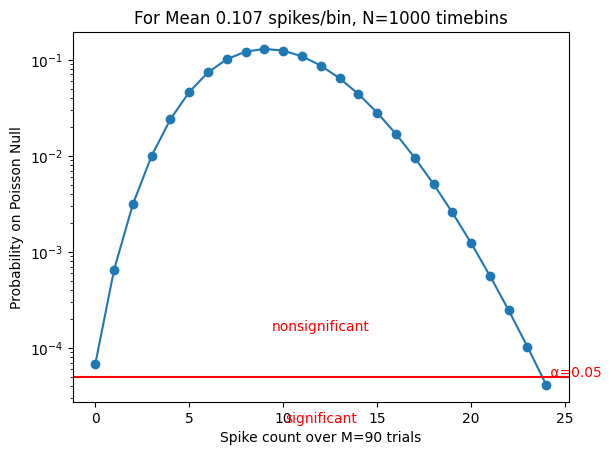

Time bins with >= 24  spikes over the  90  repeats qualify as bars


In [39]:
# Compute the threshold criterion for a sample neuron (same example selected above)
alpha=0.05 # a significance criterion
rate=FR[example]*bin_duration # rate in spikes per time bin
highThresh, lowThresh = getSpikeCountThreshold(rate, nRepeats, n_bins, alpha, True)
print('Time bins with >=',highThresh,' spikes over the ',nRepeats,' repeats qualify as bars')

In [40]:
# find_bars: helper function to return the bar code of a spike raster
def find_bars(spike_train, trial_duration, bin_duration,min_spikes):
    '''
    Identifies the times of PSTH peaks as bars of a barcode by a simple algorithm:
    All consecutive time bins above set threshold are considered to be part of the same bar, 
     the mean of those bin midpoints is considered to be the bar time
    INPUTS
        spike_train     raster for a repeated stimulus as a list of aligned spike time lists
        trial_duration  the duration of the repeated stimulus 
        bin_duration    bin size to use for the psth
        min_spikes      minimum integer number of spikes in a bin (summed over repeats)
                        for inclusion in peak identification
    OUTPUTS
        bars            times of the barcode bars in s relative to stimulus onset
        psth            the psth curve as mean number of spikes in bin per trial
        bin_midpoints   time axis for the psth
    '''
    nRepeats=len(spike_train) # number of repeats in raster
    psth=compute_psth(spike_train, trial_duration, bin_duration) # mean number of spikes in bin per trial
    significant_array = psth*nRepeats >=  min_spikes # convert psth to integer spike count to compare to minspikes
    significant_indices = np.where(significant_array)[0] #indexes to qualifying time bins
    n_bins = len(psth) 
    bin_midpoints = (np.arange(n_bins) + 0.5) * bin_duration

    # Consecutive qualifying time bins are considered part of the same "Bar"
    # The time of that bar is considered to be the mean of those bin centers
    bars = []
    current_group = []
    for idx in significant_indices:
        if not current_group or idx == current_group[-1] + 1:
            current_group.append(idx)
        else:
            bars.append(np.mean(bin_midpoints[current_group]))
            current_group = [idx]
    if current_group:
        bars.append(np.mean(bin_midpoints[current_group]))

    return bars,psth, bin_midpoints

In [41]:
# plotPSTHbarcode: helper function to plot PSTH and illustrate how bar times are derived
def plotPSTHbarcode(psth, bin_midpoints, threshold, bars, xlim =[0, 1],title='PSTH and Barcode'):
    '''
    Visualization of barcode extraction from psth
    Plots the psth, threshold, and identified peak midpoints
    INPUTS
        psth           psth expressed as mean spikes in bin over repeats
        bin_midpoints  time axis for the psth
        threshold      threshold expressed as mean spikes in bin over repeats
        bars           times of identified bars
        xlim           optional axis limits
        title          optional figure title
    '''
    fs=24 # font size
    fig, ax = plt.subplots(figsize=(30, 5))
    plt.plot(bin_midpoints, psth,  label='PSTH',color='blue')
    plt.xlabel('Time (s)',fontsize=fs)
    plt.ylabel('Mean Spike Count',fontsize=fs)
    plt.title(title,fontsize=1.5*fs)
    plt.xlim(xlim)

    # Plot threshold in red, points exceeding threshold in green
    plt.plot(bin_midpoints, threshold*np.ones_like(bin_midpoints), label='Threshold', color='red')   

    significant_array = psth >= threshold # both are in units of per-trial
    significant_indices = np.where(significant_array)[0] #indexes to qualifying time bins
    plt.scatter(bin_midpoints[significant_indices], psth[significant_indices], color='green')

    #show inferred bar times
    bar_offset = max(psth) * 1.2
    bar_height = max(psth) * 0.1
    for i, bar_x in enumerate(bars):
        plt.plot([bar_x,bar_x], bar_offset+[0,bar_height], color='black', lw=1.5)
    plt.show() 

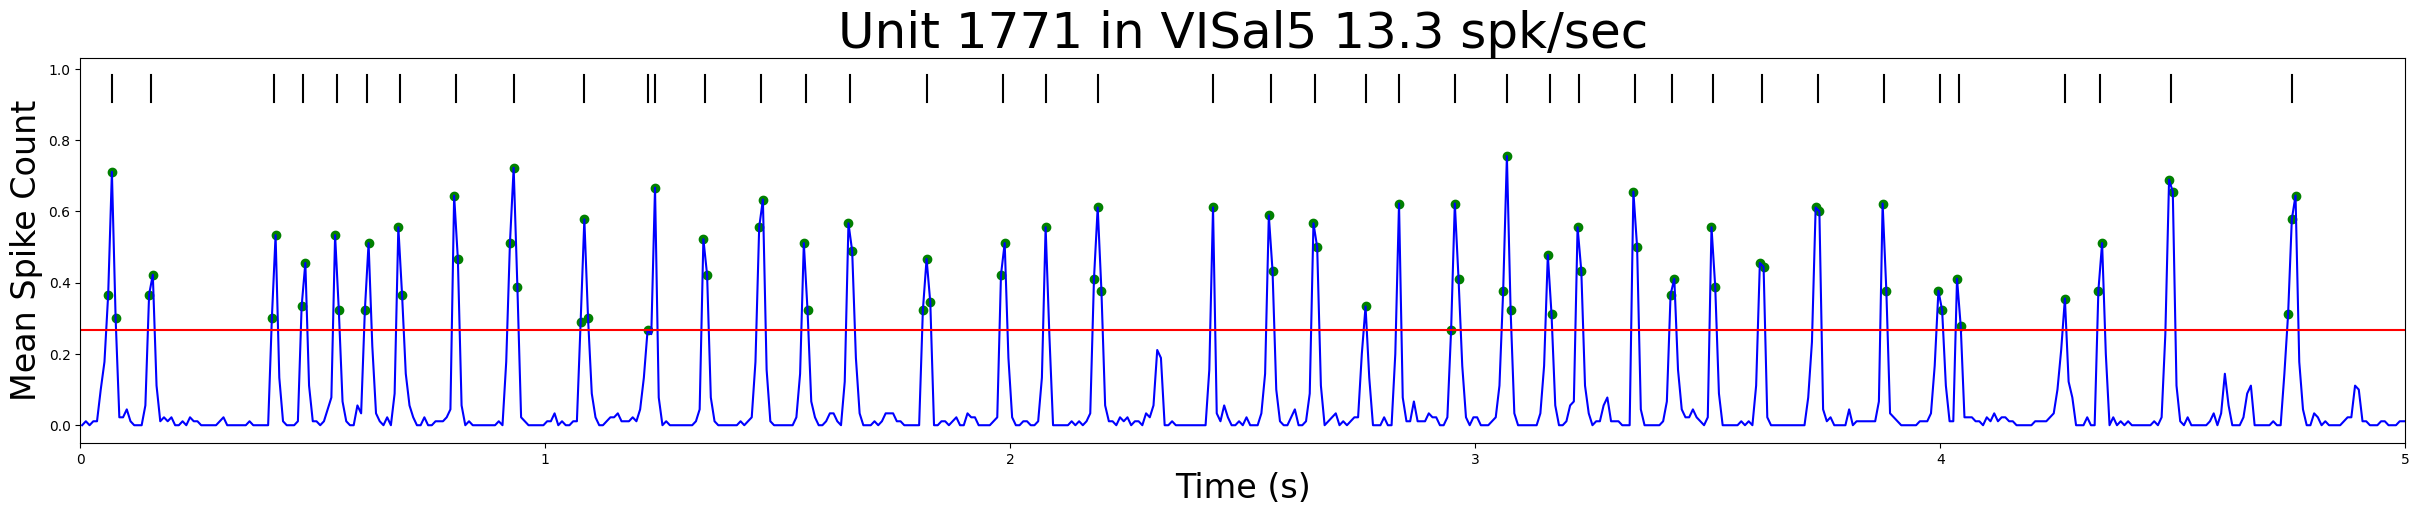

In [42]:
# Extract barcode for the example neuron and visualize it
bars, psth, t= find_bars(rasters[example], trial_duration, bin_duration, highThresh)
xlim=[0,5] # beginning and ending time to show in plot, in s
title = "Unit %d in %s %.1f spk/sec" % (example_indices[example], units_location[example_indices[example]],FR[example])
plotPSTHbarcode(psth, t, highThresh/nRepeats, bars,xlim,title)


In [43]:
# Compute the barcodes of all three example units
barcodes=[]
for i in range(len(example_indices)):
    rate=FR[example]*bin_duration # rate, expressed in spikes per time bin
    highThresh, lowThresh = getSpikeCountThreshold(rate, nRepeats, n_bins, alpha, False)
    bars, psth, t= find_bars(rasters[i], trial_duration, bin_duration, highThresh)
    barcodes.append(bars)
    print('Unit ',example_indices[i],' has ', len(bars), ' bars in its barcode')
    

Unit  0  has  0  bars in its barcode
Unit  1  has  87  bars in its barcode
Unit  2  has  0  bars in its barcode
Unit  3  has  0  bars in its barcode
Unit  4  has  0  bars in its barcode
Unit  5  has  2  bars in its barcode
Unit  6  has  18  bars in its barcode
Unit  7  has  13  bars in its barcode
Unit  8  has  0  bars in its barcode
Unit  9  has  0  bars in its barcode
Unit  10  has  100  bars in its barcode
Unit  11  has  0  bars in its barcode
Unit  13  has  75  bars in its barcode
Unit  15  has  0  bars in its barcode
Unit  16  has  0  bars in its barcode
Unit  17  has  0  bars in its barcode
Unit  18  has  4  bars in its barcode
Unit  19  has  0  bars in its barcode
Unit  20  has  1  bars in its barcode
Unit  21  has  114  bars in its barcode
Unit  22  has  0  bars in its barcode
Unit  23  has  0  bars in its barcode
Unit  24  has  0  bars in its barcode
Unit  25  has  0  bars in its barcode
Unit  28  has  0  bars in its barcode
Unit  29  has  0  bars in its barcode
Unit  30  has 

In [44]:
# spkd:  helper function implementing a simple algorithm to compute the minimum edit distance  
def spkd(tli, tlj, cost):
    '''
    Determines the minimum number of operations required to convert one bar code into the other 
    where the legal steps are to add a bar, delete a bar, or move a bar over by cost seconds
    INPUTS:
    tli        array of event times in one example, in seconds
    tlj        array of event times in another example, in seconds
    cost       number of seconds you can shift an event for the same cost as deleting or adding a spike
    
    OUTPUTS:
    d          the distance between i and j 
  
    Translated to Python by Siddharth Vyasabattu 2025 from Matlab code by Daniel Reich
    Translated to Matlab by Daniel Reich 1999 from FORTRAN code by Jonathan Victor
    (used with permission from JV)
    
    '''
    nspi = len(tli)
    nspj = len(tlj)

    if cost == 0:
        return abs(nspi - nspj)
    elif cost == float('inf'):
        return nspi + nspj

    # Initialize the cost matrix
    scr = np.zeros((nspi + 1, nspj + 1))

    # Margins with the cost of adding a spike
    scr[:, 0] = np.arange(nspi + 1)
    scr[0, :] = np.arange(nspj + 1)

    # Calculate the costs for aligning spike trains
    if nspi > 0 and nspj > 0:
        for i in range(1, nspi + 1):
            for j in range(1, nspj + 1):
                scr[i, j] = min(
                    scr[i - 1, j] + 1,
                    scr[i, j - 1] + 1,
                    scr[i - 1, j - 1] + cost * abs(tli[i - 1] - tlj[j - 1])
                )
    d = scr[nspi, nspj]  #the distance metric
    return d

In [45]:
Barcode_A = barcodes[1042]     #times of the bars, in s
Barcode_B = barcodes[1043]  
Barcode_A, Barcode_B

([np.float64(0.068),
  np.float64(0.152),
  np.float64(0.41600000000000004),
  np.float64(0.48),
  np.float64(0.552),
  np.float64(0.616),
  np.float64(0.6880000000000001),
  np.float64(0.808),
  np.float64(0.932),
  np.float64(1.084),
  np.float64(1.22),
  np.float64(1.236),
  np.float64(1.344),
  np.float64(1.464),
  np.float64(1.56),
  np.float64(1.6560000000000001),
  np.float64(1.82),
  np.float64(1.984),
  np.float64(2.076),
  np.float64(2.188),
  np.float64(2.436),
  np.float64(2.56),
  np.float64(2.656),
  np.float64(2.7640000000000002),
  np.float64(2.836),
  np.float64(2.956),
  np.float64(3.068),
  np.float64(3.16),
  np.float64(3.224),
  np.float64(3.344),
  np.float64(3.424),
  np.float64(3.512),
  np.float64(3.616),
  np.float64(3.736),
  np.float64(3.88),
  np.float64(4.0),
  np.float64(4.040000000000001),
  np.float64(4.268),
  np.float64(4.343999999999999),
  np.float64(4.496),
  np.float64(4.756),
  np.float64(5.0360000000000005),
  np.float64(5.18),
  np.float64(5.29

In [46]:
cost = 1 # cost per 1s shift in a spike time
#spkd(Barcode_A, Barcode_B, cost)

for i in range(len(barcodes) - 1):
    barcode_dist = spkd(barcodes[i], barcodes[i + 1], cost)

print(barcode_dist)

0.0


In [47]:
# recall the bar code lengths
for i in range(len(barcodes) - 1):
    print('Unit ',example_indices[i],' has ', len(barcodes[i]), ' bars in its barcode')
    
print('Worst case, deleting all the bars of the first and inserting all the bars of the second')
print('would cost ',len(barcodes[0]),' + ',len(barcodes[1]),' = ',len(barcodes[0])+len(barcodes[1]))

# choose a cost parameter
cost=125
# two spikes will be aligned if it is "cheaper" than deleting one and inserting the other
print('cost = ',cost,' means bars will be matched if they are <',2000/cost,' ms apart')

# The distance between the full length barcodes
d=spkd(barcodes[0],barcodes[1], cost)
print('For a cost of ',cost,' the distance is = ',np.round(d,1))

Unit  0  has  0  bars in its barcode
Unit  1  has  87  bars in its barcode
Unit  2  has  0  bars in its barcode
Unit  3  has  0  bars in its barcode
Unit  4  has  0  bars in its barcode
Unit  5  has  2  bars in its barcode
Unit  6  has  18  bars in its barcode
Unit  7  has  13  bars in its barcode
Unit  8  has  0  bars in its barcode
Unit  9  has  0  bars in its barcode
Unit  10  has  100  bars in its barcode
Unit  11  has  0  bars in its barcode
Unit  13  has  75  bars in its barcode
Unit  15  has  0  bars in its barcode
Unit  16  has  0  bars in its barcode
Unit  17  has  0  bars in its barcode
Unit  18  has  4  bars in its barcode
Unit  19  has  0  bars in its barcode
Unit  20  has  1  bars in its barcode
Unit  21  has  114  bars in its barcode
Unit  22  has  0  bars in its barcode
Unit  23  has  0  bars in its barcode
Unit  24  has  0  bars in its barcode
Unit  25  has  0  bars in its barcode
Unit  28  has  0  bars in its barcode
Unit  29  has  0  bars in its barcode
Unit  30  has 

In [48]:
# To illustrate suppose a barcode had bars at 2, 4 and 7s
,examplebarcode = np.asarray(barcodes[1042], dtype=float).copy()
print('example bar code = ', examplebarcode)

# and suppose the random offset was 1.5s
offset = 1.5
print('offset = ', offset)

# this adds the offset to each bar's time without mutating the original barcode
shifted_example = examplebarcode + offset
print('shifted bar code = ', shifted_example)
print('stimulus duration = ', trial_duration)

# this wraps the values exceeding the trial duration back to 
# the beginning and sorts them in order again
permutedexample = np.sort(shifted_example % trial_duration)
print('permuted bar code = ', permutedexample)

NameError: name 'examplebarcode' is not defined

In [ ]:
# permute_barcode: helper function to permute barcodes
def permute_barcode(barcode, trial_duration):
    barcode_arr = np.asarray(barcode, dtype=float)
    random_offset = np.random.uniform(0, trial_duration)
    permutedcode = np.sort((barcode_arr + random_offset) % trial_duration)
    return permutedcode

In [ ]:
permuted_barcode1 = permute_barcode(barcodes[1041], trial_duration)
control_d = spkd(permuted_barcode1, barcodes[1042], cost)
print('For a shift cost of ',cost)
print('The distance from permuted neuron1 to neuron2 was ',np.round(control_d,1))

For a shift cost of  125
The distance from permuted neuron1 to neuron2 was  66.0


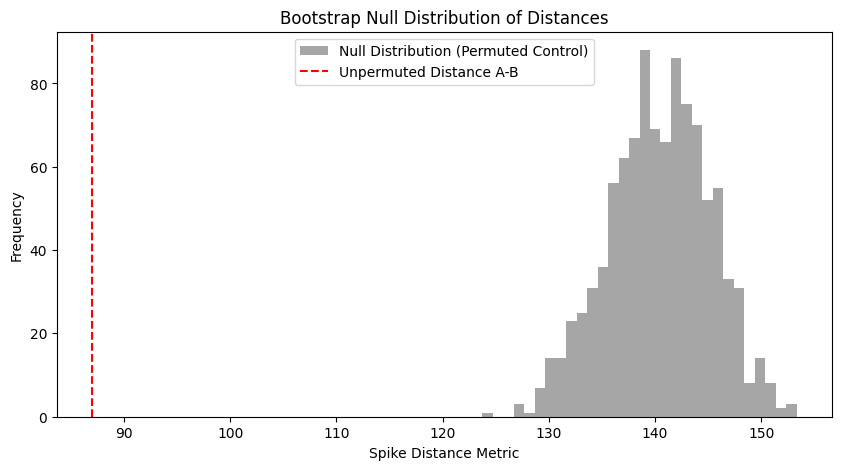

In [ ]:
perm_barcode_dist = []
for i in range(1000):
    permuted_barcode1 =  permute_barcode(barcodes[10], trial_duration)
    perm_barcode_dist.append(spkd(permuted_barcode1, barcodes[1042], cost))
plt.figure(figsize=(10, 5))
plt.hist(perm_barcode_dist, bins=30, color='gray', alpha=0.7, label="Null Distribution (Permuted Control)")
plt.axvline(x=d, color='red', linestyle='--', label="Unpermuted Distance A-B")
plt.xlabel("Spike Distance Metric")
plt.ylabel("Frequency")
plt.title("Bootstrap Null Distribution of Distances")
plt.legend()
plt.show()

Clustering/PCA summary
Number of neurons clustered: 1511
K-means cluster sizes: [1427   12   71    1]
PCA explained variance ratio: [0.371 0.179]

Cluster x Brain Region counts:


brain_region,APN,CA1,CA2,CA3,DG-mo,DG-po,DG-sg,HPF,LGd-co,LGd-ip,...,VISl6b,VISp2/3,VISp4,VISp5,VISp6a,VISpm2/3,VISpm4,VISpm5,VISpm6a,root
cluster,,,,,,,,,,,,,,,,,,,,,
0,113,247,2,29,18,1,41,5,47,11,...,5,15,32,58,20,16,19,73,22,11
1,4,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,7,3,0,0,0,0,0,0,18,1,...,0,0,0,8,4,1,0,3,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Cluster x Genotype counts:


genotype,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
cluster,
0,1427
1,12
2,71
3,1



Per-cluster summary:


,n_units,mean_barcode_len,median_barcode_len
cluster,,,
0,1427,1.405746,0.0
1,12,156.166667,155.5
2,71,61.338028,56.0
3,1,229.000000,229.0


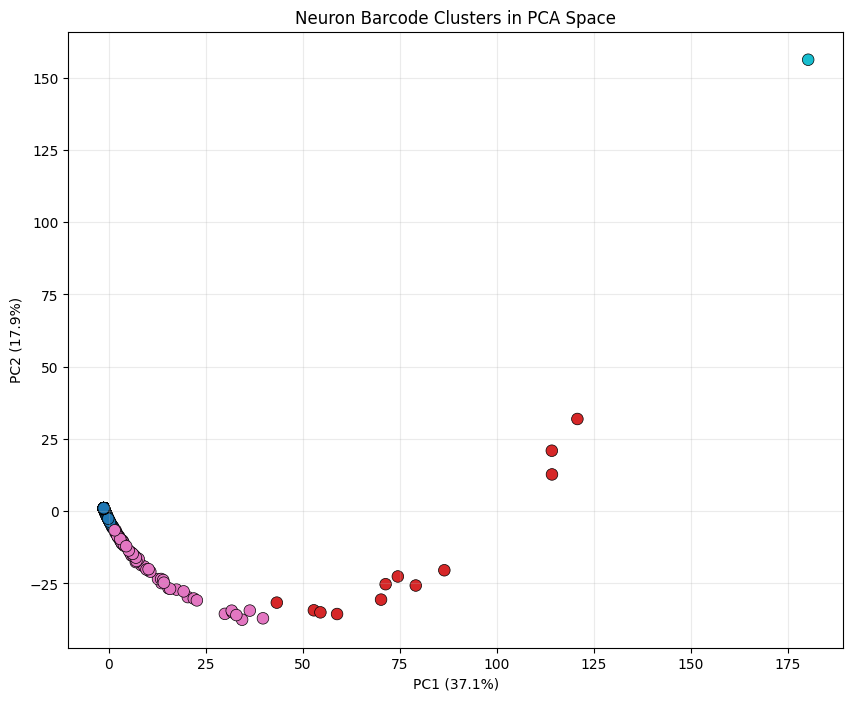

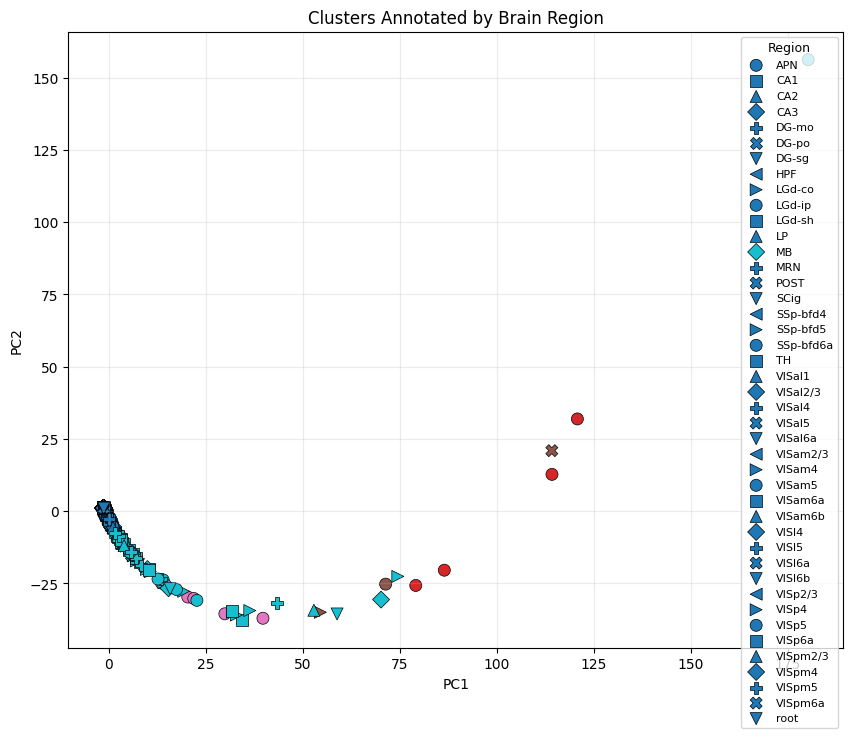

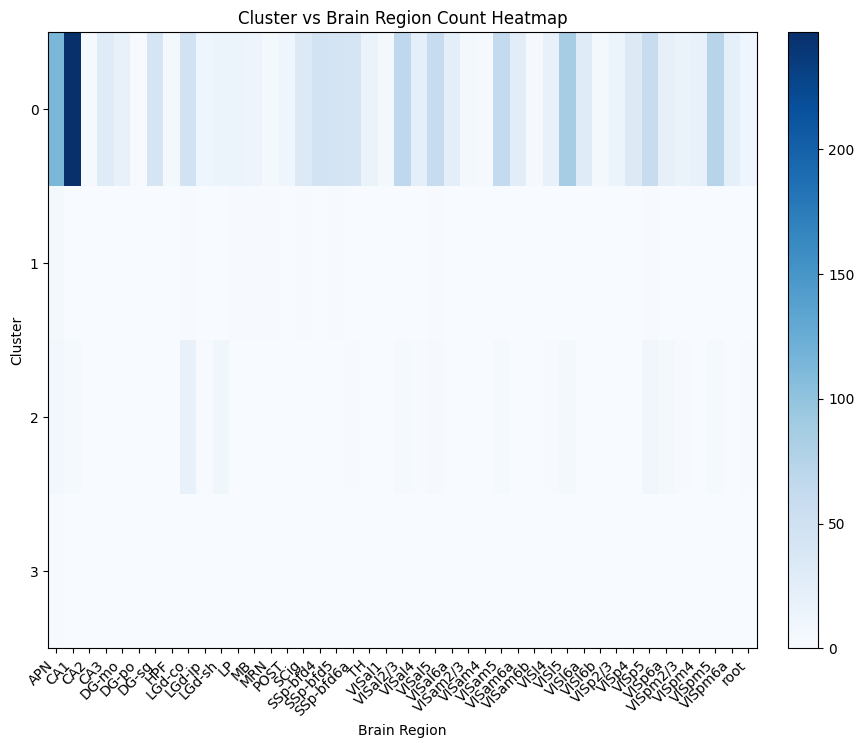

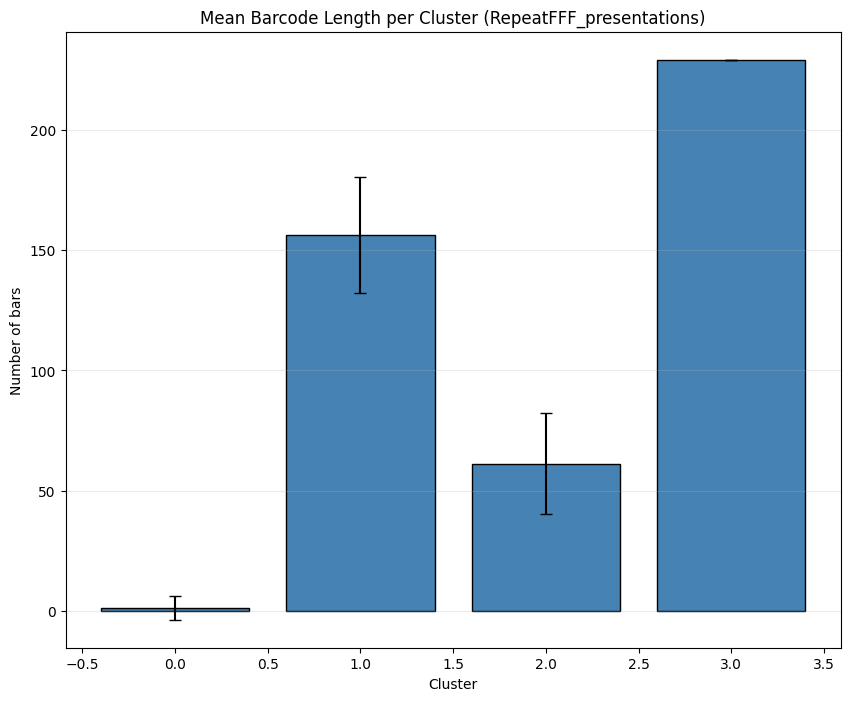


Stimuli available in this session:
['RepeatFFF_presentations', 'UniqueFFF_presentations', 'invalid_times', 'receptive_field_block_presentations', 'static_block_presentations']
Barcode extraction stimulus context: RepeatFFF_presentations
Note: genotype is constant in this single-session NWB, so cluster-genotype differences cannot be assessed here.


In [ ]:
# Cluster neurons by barcode similarity: K-means first, then PCA projection
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

if len(barcodes) < 2:
    raise ValueError('Need at least 2 extracted barcodes to cluster neurons.')

# Copy barcode data defensively to avoid in-place mutations from exploratory cells.
barcode_list = [np.asarray(barcode, dtype=float).copy() for barcode in barcodes]

# Map each extracted barcode row to a neuron/unit id
example_indices = globals().get('example_indices', globals().get('goodUnits', list(range(len(barcode_list)))))
unit_ids = np.asarray(example_indices[:len(barcode_list)], dtype=int)
if len(unit_ids) != len(barcode_list):
    raise ValueError('Mismatch between barcode rows and mapped unit IDs.')

if trial_duration <= 0:
    raise ValueError('trial_duration must be positive before feature normalization.')

barcode_lengths = np.array([len(barcode) for barcode in barcode_list], dtype=float)
max_len = int(max(barcode_lengths)) if len(barcode_lengths) else 0
if max_len == 0:
    raise ValueError('All extracted barcodes are empty; clustering/PCA cannot be computed meaningfully.')

# Build fixed-width feature matrix from extracted barcodes (timing normalized by trial duration)
barcode_matrix = np.full((len(barcode_list), max_len), np.nan, dtype=float)
for row_idx, barcode in enumerate(barcode_list):
    barcode_matrix[row_idx, :len(barcode)] = barcode / trial_duration

# Include barcode length as an explicit structural feature
feature_matrix = np.hstack([barcode_matrix, (barcode_lengths / max_len).reshape(-1, 1)])

imputer = SimpleImputer(strategy='constant', fill_value=0.0)
scaler = StandardScaler()
X = scaler.fit_transform(imputer.fit_transform(feature_matrix))

# 1) K-means clustering in feature space
n_clusters = min(4, len(barcode_list))
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=20)
cluster_labels = kmeans.fit_predict(X)

# 2) PCA projection for visualization
n_components = min(2, X.shape[0], X.shape[1])
if n_components < 1:
    raise ValueError('PCA requires at least one valid component.')

pca = PCA(n_components=n_components, random_state=0)
embedding = pca.fit_transform(X)
if embedding.shape[1] == 1:
    embedding_plot = np.column_stack([embedding[:, 0], np.zeros(len(embedding))])
else:
    embedding_plot = embedding[:, :2]

pc_variance = pca.explained_variance_ratio_
pc1_var = float(pc_variance[0]) if len(pc_variance) >= 1 else 0.0
pc2_var = float(pc_variance[1]) if len(pc_variance) >= 2 else 0.0

print('Clustering/PCA summary')
print('Number of neurons clustered:', len(barcode_list))
print('K-means cluster sizes:', np.bincount(cluster_labels))
print('PCA explained variance ratio:', np.round(pc_variance, 3))

# --- Metadata linkage ---
region_labels = np.array(units_location[unit_ids], dtype=str)
cluster_region_table = pd.crosstab(
    pd.Series(cluster_labels, name='cluster'),
    pd.Series(region_labels, name='brain_region')
)

session_genotype = getattr(getattr(nwb, 'subject', None), 'genotype', 'unknown')
genotype_labels = np.array([str(session_genotype)] * len(barcode_list))
cluster_genotype_table = pd.crosstab(
    pd.Series(cluster_labels, name='cluster'),
    pd.Series(genotype_labels, name='genotype')
)

stim_names_available = list(nwb.intervals.keys())
stimulus_context = stimTypeToExtract if 'stimTypeToExtract' in globals() else 'unknown_stimulus'
cluster_summary = pd.DataFrame({
    'unit_id': unit_ids,
    'cluster': cluster_labels,
    'brain_region': region_labels,
    'barcode_len': barcode_lengths,
    'stimulus_used_for_barcode': stimulus_context,
})

print('\nCluster x Brain Region counts:')
display(cluster_region_table)
print('\nCluster x Genotype counts:')
display(cluster_genotype_table)
print('\nPer-cluster summary:')
display(cluster_summary.groupby('cluster').agg(
    n_units=('unit_id', 'count'),
    mean_barcode_len=('barcode_len', 'mean'),
    median_barcode_len=('barcode_len', 'median'),
))

# ------------------------
# Visualization suite
# ------------------------

# 1) PCA scatter colored by cluster
plt.figure(figsize=(10, 8))
plt.scatter(
    embedding_plot[:, 0], embedding_plot[:, 1],
    c=cluster_labels, cmap='tab10', s=70, edgecolor='black', linewidth=0.5
)
plt.title('Neuron Barcode Clusters in PCA Space')
plt.xlabel(f'PC1 ({pc1_var * 100:.1f}%)')
plt.ylabel(f'PC2 ({pc2_var * 100:.1f}%)')
plt.grid(alpha=0.25)
plt.show()

# 2) PCA scatter with brain-region markers
plt.figure(figsize=(10, 8))
region_list = np.unique(region_labels)
markers = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']
for r_idx, region in enumerate(region_list):
    mask = region_labels == region
    plt.scatter(
        embedding_plot[mask, 0], embedding_plot[mask, 1],
        c=cluster_labels[mask], cmap='tab10',
        marker=markers[r_idx % len(markers)], s=75, edgecolor='black', linewidth=0.5,
        label=region
    )
plt.title('Clusters Annotated by Brain Region')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.25)
plt.legend(title='Region', fontsize=8, title_fontsize=9, loc='best')
plt.show()

# 3) Heatmap: cluster vs region counts
plt.figure(figsize=(10, 8))
heatmap_data = cluster_region_table.values
im = plt.imshow(heatmap_data, aspect='auto', cmap='Blues')
plt.title('Cluster vs Brain Region Count Heatmap')
plt.xlabel('Brain Region')
plt.ylabel('Cluster')
plt.xticks(np.arange(cluster_region_table.shape[1]), cluster_region_table.columns, rotation=45, ha='right')
plt.yticks(np.arange(cluster_region_table.shape[0]), cluster_region_table.index)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

# 4) Cluster barcode-size summary (stimulus-specific barcode complexity)
plt.figure(figsize=(10, 8))
cluster_means = cluster_summary.groupby('cluster')['barcode_len'].mean()
cluster_stds = cluster_summary.groupby('cluster')['barcode_len'].std().fillna(0)
plt.bar(cluster_means.index, cluster_means.values, yerr=cluster_stds.values, color='steelblue', edgecolor='black', capsize=4)
plt.title(f'Mean Barcode Length per Cluster ({stimulus_context})')
plt.xlabel('Cluster')
plt.ylabel('Number of bars')
plt.grid(axis='y', alpha=0.25)
plt.show()

print('\nStimuli available in this session:')
print(stim_names_available)
print('Barcode extraction stimulus context:', stimulus_context)
if len(np.unique(genotype_labels)) == 1:
    print('Note: genotype is constant in this single-session NWB, so cluster-genotype differences cannot be assessed here.')

Alternative clustering/embedding summary
Method: t-SNE (perplexity=30)
Number of neurons clustered: 1511
Agglomerative cluster sizes: [  19   72    1 1419]

Agglomerative Cluster x Brain Region counts:


brain_region,APN,CA1,CA2,CA3,DG-mo,DG-po,DG-sg,HPF,LGd-co,LGd-ip,...,VISl6b,VISp2/3,VISp4,VISp5,VISp6a,VISpm2/3,VISpm4,VISpm5,VISpm6a,root
cluster,,,,,,,,,,,,,,,,,,,,,
0,6,1,0,0,0,0,0,0,4,0,...,0,0,0,1,0,0,0,0,0,0
1,5,2,0,0,0,0,0,0,17,1,...,0,0,0,10,4,2,0,3,0,1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,113,247,2,29,18,1,41,5,45,11,...,5,15,32,56,20,15,19,73,22,11



Agglomerative Cluster x Genotype counts:


genotype,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
cluster,
0,19
1,72
2,1
3,1419



Agglomerative per-cluster summary:


,n_units,mean_barcode_len,median_barcode_len
cluster,,,
0,19,138.000000,133.0
1,72,53.805556,49.0
2,1,229.000000,229.0
3,1419,1.225511,0.0


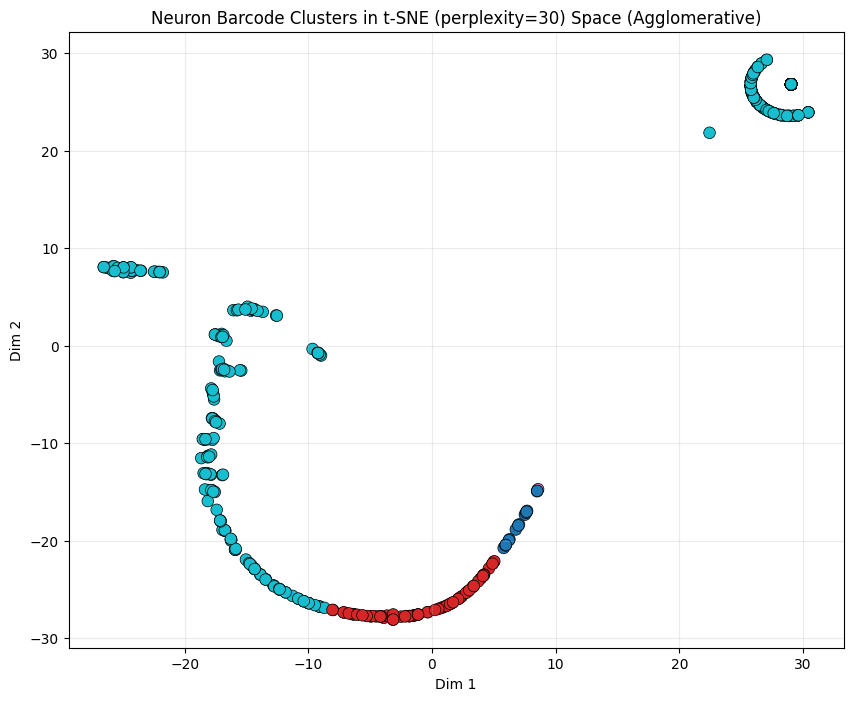

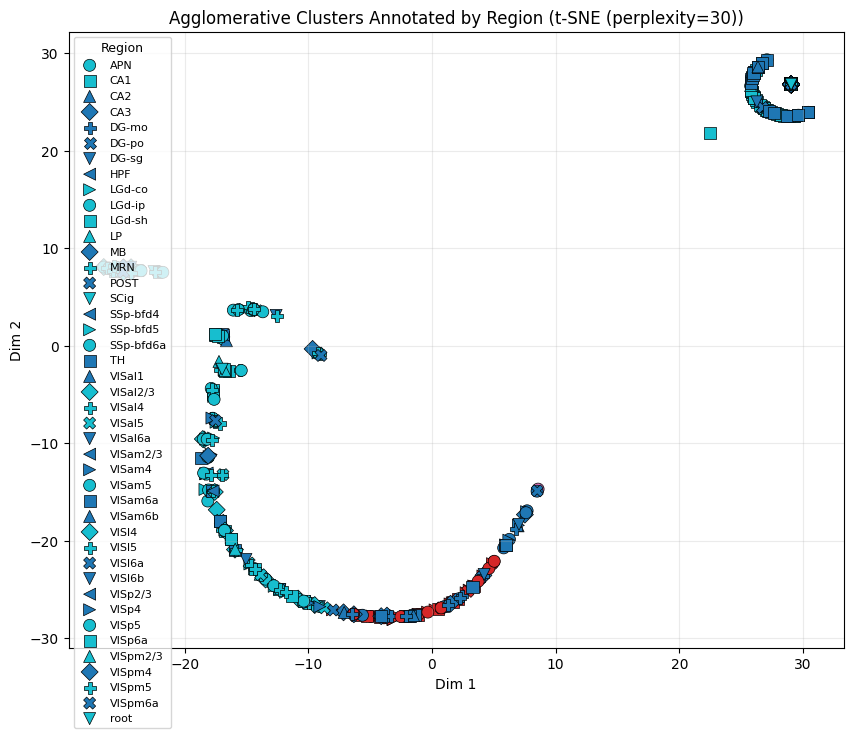

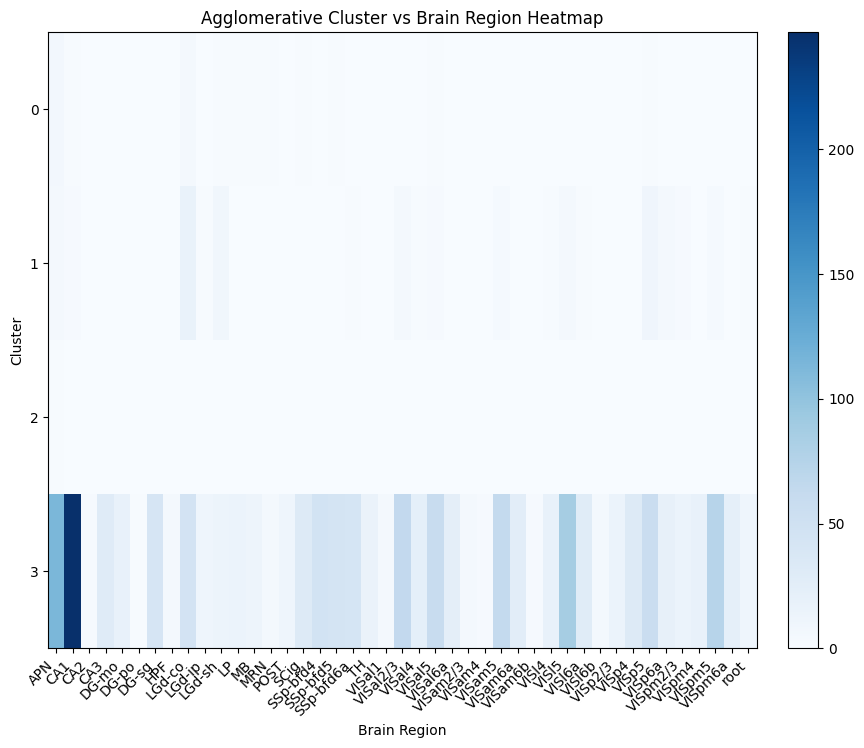

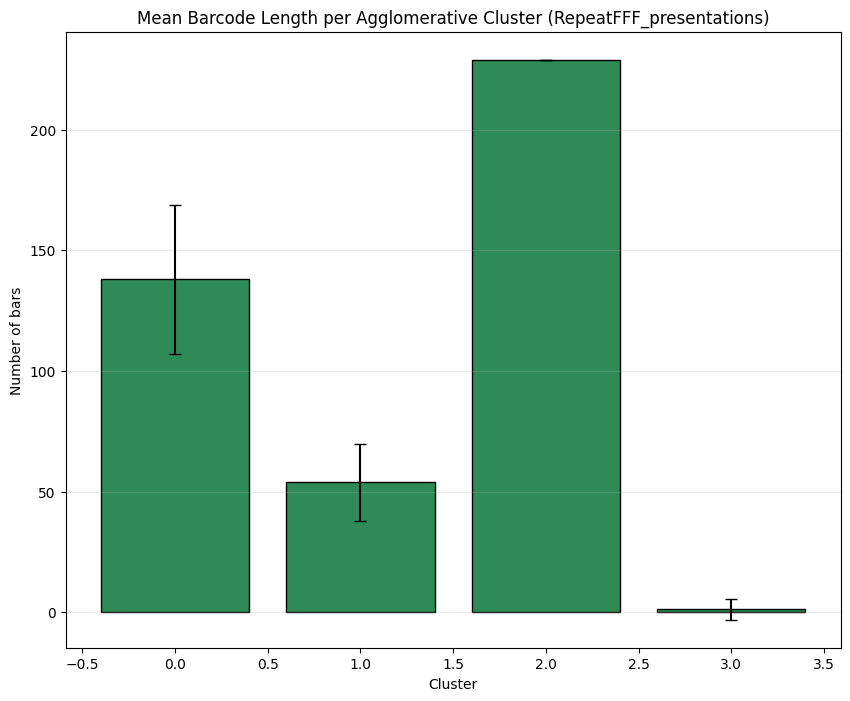

Note: genotype is constant in this single-session NWB, so cluster-genotype differences cannot be assessed here.


In [ ]:
# Alternative pipeline: Agglomerative clustering + nonlinear embedding (UMAP, fallback t-SNE)
import importlib
from sklearn.cluster import AgglomerativeClustering
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

required_globals = ['barcodes', 'trial_duration', 'units_location', 'nwb']
missing = [name for name in required_globals if name not in globals()]
if missing:
    raise ValueError(f'Run prerequisite cells first. Missing: {missing}')

umap_spec = importlib.util.find_spec('umap')
if umap_spec is not None:
    umap = importlib.import_module('umap')
    has_umap = True
else:
    has_umap = False

if len(barcodes) < 2:
    raise ValueError('Need at least 2 extracted barcodes for alternative clustering.')

barcode_list_alt = [np.asarray(barcode, dtype=float).copy() for barcode in barcodes]
example_indices_alt = globals().get('example_indices', globals().get('goodUnits', list(range(len(barcode_list_alt)))))
unit_ids_alt = np.asarray(example_indices_alt[:len(barcode_list_alt)], dtype=int)
if len(unit_ids_alt) != len(barcode_list_alt):
    raise ValueError('Mismatch between barcode rows and mapped unit IDs.')

if trial_duration <= 0:
    raise ValueError('trial_duration must be positive before feature normalization.')

barcode_lengths_alt = np.array([len(barcode) for barcode in barcode_list_alt], dtype=float)
max_len_alt = int(max(barcode_lengths_alt)) if len(barcode_lengths_alt) else 0
if max_len_alt == 0:
    raise ValueError('All extracted barcodes are empty; alternative clustering cannot be computed meaningfully.')

barcode_matrix_alt = np.full((len(barcode_list_alt), max_len_alt), np.nan, dtype=float)
for row_idx, barcode in enumerate(barcode_list_alt):
    barcode_matrix_alt[row_idx, :len(barcode)] = barcode / trial_duration

feature_matrix_alt = np.hstack([barcode_matrix_alt, (barcode_lengths_alt / max_len_alt).reshape(-1, 1)])
imputer_alt = SimpleImputer(strategy='constant', fill_value=0.0)
scaler_alt = StandardScaler()
X_alt = scaler_alt.fit_transform(imputer_alt.fit_transform(feature_matrix_alt))

n_clusters_alt = min(4, len(barcode_list_alt))
agg = AgglomerativeClustering(n_clusters=n_clusters_alt, linkage='ward')
agg_labels = agg.fit_predict(X_alt)

if has_umap and len(barcode_list_alt) >= 3:
    n_neighbors = min(15, len(barcode_list_alt) - 1)
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=0.1,
        metric='euclidean',
        random_state=0,
    )
    embedding_alt = reducer.fit_transform(X_alt)
    embedding_method = f'UMAP (n_neighbors={n_neighbors})'
elif len(barcode_list_alt) >= 3:
    perplexity = min(30, len(barcode_list_alt) - 1)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init='pca',
        learning_rate='auto',
        random_state=0,
    )
    embedding_alt = tsne.fit_transform(X_alt)
    embedding_method = f't-SNE (perplexity={perplexity})'
else:
    embedding_alt = np.column_stack([X_alt[:, 0], np.zeros(len(X_alt))])
    embedding_method = 'Feature-axis projection (n < 3)'

print('Alternative clustering/embedding summary')
print('Method:', embedding_method)
print('Number of neurons clustered:', len(barcode_list_alt))
print('Agglomerative cluster sizes:', np.bincount(agg_labels))

region_labels_alt = np.array(units_location[unit_ids_alt], dtype=str)
cluster_region_table_alt = pd.crosstab(
    pd.Series(agg_labels, name='cluster'),
    pd.Series(region_labels_alt, name='brain_region')
)

session_genotype_alt = getattr(getattr(nwb, 'subject', None), 'genotype', 'unknown')
genotype_labels_alt = np.array([str(session_genotype_alt)] * len(barcode_list_alt))
cluster_genotype_table_alt = pd.crosstab(
    pd.Series(agg_labels, name='cluster'),
    pd.Series(genotype_labels_alt, name='genotype')
)

stimulus_context_alt = stimTypeToExtract if 'stimTypeToExtract' in globals() else 'unknown_stimulus'
cluster_summary_alt = pd.DataFrame({
    'unit_id': unit_ids_alt,
    'cluster': agg_labels,
    'brain_region': region_labels_alt,
    'barcode_len': barcode_lengths_alt,
    'stimulus_used_for_barcode': stimulus_context_alt,
})

print('\nAgglomerative Cluster x Brain Region counts:')
display(cluster_region_table_alt)
print('\nAgglomerative Cluster x Genotype counts:')
display(cluster_genotype_table_alt)
print('\nAgglomerative per-cluster summary:')
display(cluster_summary_alt.groupby('cluster').agg(
    n_units=('unit_id', 'count'),
    mean_barcode_len=('barcode_len', 'mean'),
    median_barcode_len=('barcode_len', 'median'),
))

plt.figure(figsize=(10, 8))
plt.scatter(
    embedding_alt[:, 0], embedding_alt[:, 1],
    c=agg_labels, cmap='tab10', s=70, edgecolor='black', linewidth=0.5
)
plt.title(f'Neuron Barcode Clusters in {embedding_method} Space (Agglomerative)')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 8))
region_list_alt = np.unique(region_labels_alt)
markers_alt = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']
for r_idx, region in enumerate(region_list_alt):
    mask = region_labels_alt == region
    plt.scatter(
        embedding_alt[mask, 0], embedding_alt[mask, 1],
        c=agg_labels[mask], cmap='tab10',
        marker=markers_alt[r_idx % len(markers_alt)], s=75, edgecolor='black', linewidth=0.5,
        label=region,
    )
plt.title(f'Agglomerative Clusters Annotated by Region ({embedding_method})')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.grid(alpha=0.25)
plt.legend(title='Region', fontsize=8, title_fontsize=9, loc='best')
plt.show()

plt.figure(figsize=(10, 8))
heatmap_data_alt = cluster_region_table_alt.values
im = plt.imshow(heatmap_data_alt, aspect='auto', cmap='Blues')
plt.title('Agglomerative Cluster vs Brain Region Heatmap')
plt.xlabel('Brain Region')
plt.ylabel('Cluster')
plt.xticks(
    np.arange(cluster_region_table_alt.shape[1]),
    cluster_region_table_alt.columns,
    rotation=45,
    ha='right',
)
plt.yticks(np.arange(cluster_region_table_alt.shape[0]), cluster_region_table_alt.index)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

plt.figure(figsize=(10, 8))
cluster_means_alt = cluster_summary_alt.groupby('cluster')['barcode_len'].mean()
cluster_stds_alt = cluster_summary_alt.groupby('cluster')['barcode_len'].std().fillna(0)
plt.bar(
    cluster_means_alt.index,
    cluster_means_alt.values,
    yerr=cluster_stds_alt.values,
    color='seagreen',
    edgecolor='black',
    capsize=4,
    )
plt.title(f'Mean Barcode Length per Agglomerative Cluster ({stimulus_context_alt})')
plt.xlabel('Cluster')
plt.ylabel('Number of bars')
plt.grid(axis='y', alpha=0.25)
plt.show()

if len(np.unique(genotype_labels_alt)) == 1:
    print('Note: genotype is constant in this single-session NWB, so cluster-genotype differences cannot be assessed here.')

Comparison protocol summary
ARI (KMeans vs Agglomerative): 0.945
NMI (KMeans vs Agglomerative): 0.856
Interpretation: ARI/NMI near 1 means strong agreement in assignments.

Cluster-assignment contingency table:


Agglomerative cluster,0,1,2,3
KMeans cluster,,,,
0,0,8,0,1419
1,12,0,0,0
2,7,64,0,0
3,0,0,1,0



Clustering quality metrics:


,model,silhouette_on_X,calinski_harabasz_on_X,davies_bouldin_on_X,silhouette_on_PCA2D,silhouette_on_Alt2D
0,KMeans labels,0.865,738.931,0.855,0.941,0.607
1,Agglomerative labels,0.858,701.288,0.908,0.940,0.619



Embedding faithfulness metrics:


,embedding,trustworthiness_vs_X
0,PCA 2D,0.897
1,Alternative 2D,0.941


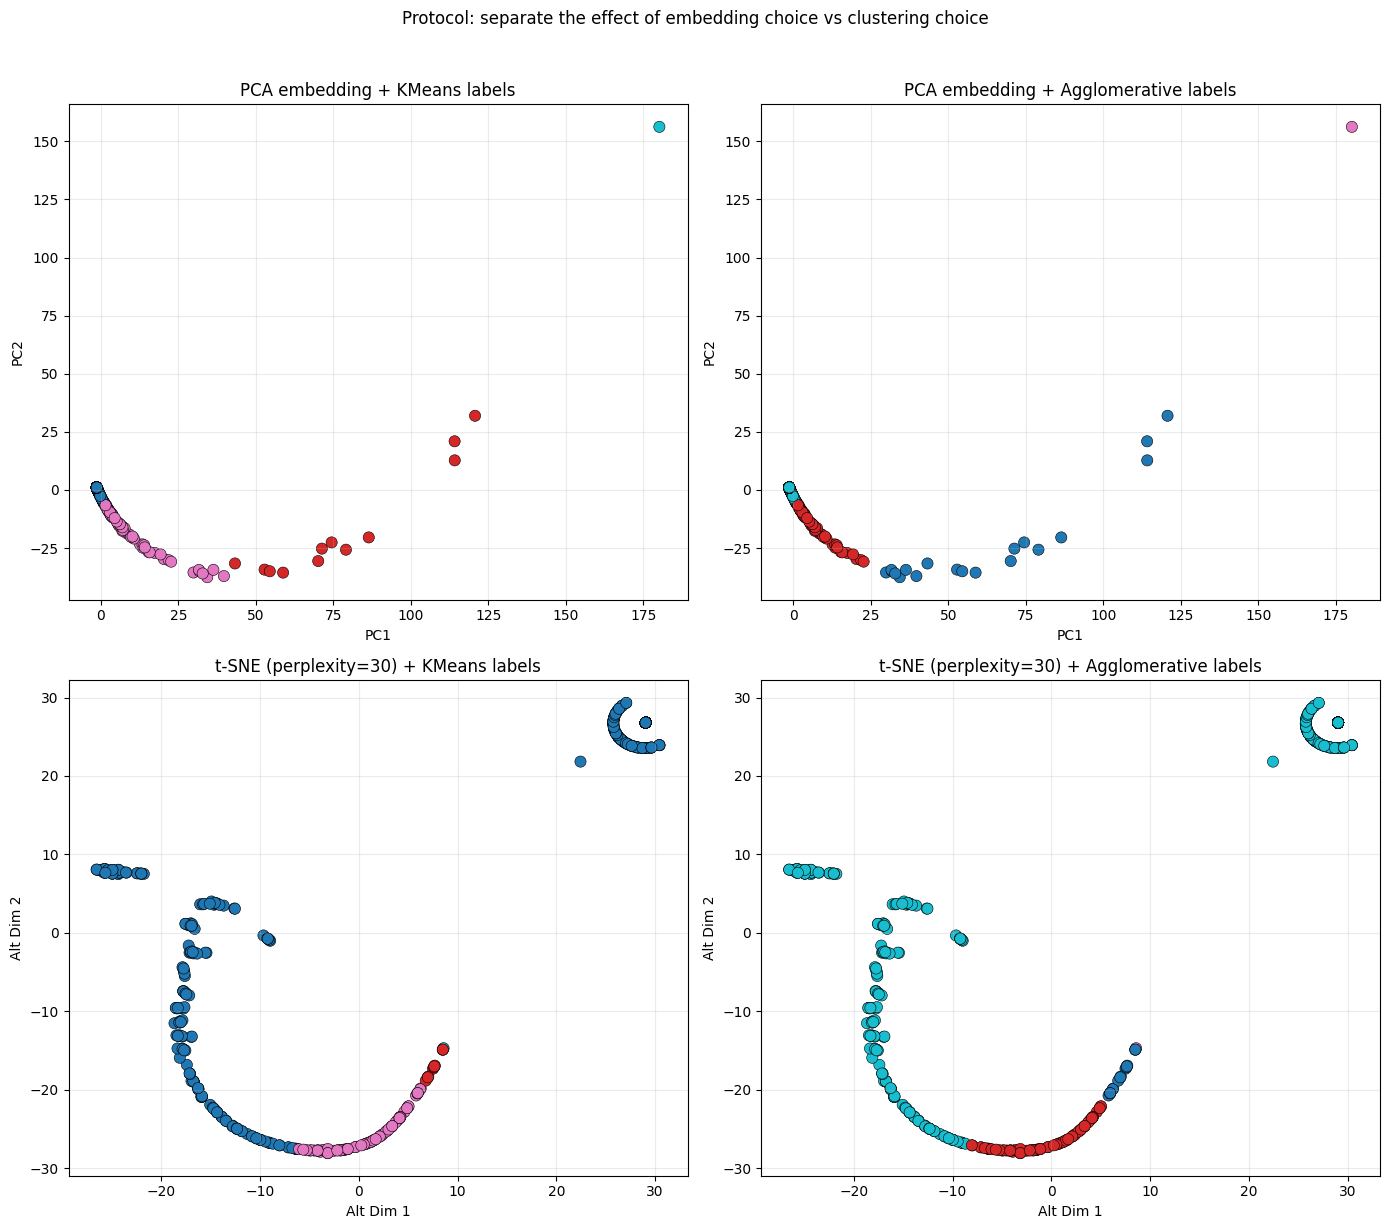

In [ ]:
# Comparison protocol: same points, crossed embedding/cluster views + quantitative agreement metrics
from sklearn.manifold import trustworthiness
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
 )

required = ['X', 'embedding_plot', 'embedding_alt', 'cluster_labels', 'agg_labels']
missing = [name for name in required if name not in globals()]
if missing:
    raise ValueError(f'Run the PCA/K-means and Agglomerative embedding cells first. Missing: {missing}')

X_cmp = np.asarray(X)
kmeans_labels_cmp = np.asarray(cluster_labels)
agg_labels_cmp = np.asarray(agg_labels)

if X_cmp.ndim != 2 or X_cmp.shape[0] < 2:
    raise ValueError('Need at least 2 samples in X for comparison metrics.')
if len(kmeans_labels_cmp) != X_cmp.shape[0] or len(agg_labels_cmp) != X_cmp.shape[0]:
    raise ValueError('Label arrays must match number of rows in X.')

pca_2d = np.asarray(embedding_plot)
alt_2d = np.asarray(embedding_alt)
if pca_2d.ndim != 2 or pca_2d.shape[1] < 2:
    raise ValueError('PCA embedding must be at least 2D.')
if alt_2d.ndim != 2:
    raise ValueError('Alternative embedding must be 2D array.')
if alt_2d.shape[1] == 1:
    alt_2d = np.column_stack([alt_2d[:, 0], np.zeros(len(alt_2d))])
elif alt_2d.shape[1] > 2:
    alt_2d = alt_2d[:, :2]

if len(np.unique(kmeans_labels_cmp)) < 2 or len(np.unique(agg_labels_cmp)) < 2:
    raise ValueError('Need at least 2 clusters in each labeling for comparison.')

def safe_metric(fn, *args, **kwargs):
    try:
        return float(fn(*args, **kwargs))
    except Exception:
        return np.nan

# Cluster-label agreement (embedding independent)
ari = adjusted_rand_score(kmeans_labels_cmp, agg_labels_cmp)
nmi = normalized_mutual_info_score(kmeans_labels_cmp, agg_labels_cmp)

# Clustering quality in original feature space X
sil_kmeans_x = safe_metric(silhouette_score, X_cmp, kmeans_labels_cmp)
sil_agg_x = safe_metric(silhouette_score, X_cmp, agg_labels_cmp)
ch_kmeans_x = safe_metric(calinski_harabasz_score, X_cmp, kmeans_labels_cmp)
ch_agg_x = safe_metric(calinski_harabasz_score, X_cmp, agg_labels_cmp)
db_kmeans_x = safe_metric(davies_bouldin_score, X_cmp, kmeans_labels_cmp)
db_agg_x = safe_metric(davies_bouldin_score, X_cmp, agg_labels_cmp)

# Optional: label separation within each 2D embedding view
sil_kmeans_pca = safe_metric(silhouette_score, pca_2d, kmeans_labels_cmp)
sil_agg_pca = safe_metric(silhouette_score, pca_2d, agg_labels_cmp)
sil_kmeans_alt = safe_metric(silhouette_score, alt_2d, kmeans_labels_cmp)
sil_agg_alt = safe_metric(silhouette_score, alt_2d, agg_labels_cmp)

# Embedding faithfulness to X (higher is better)
n_neighbors = min(10, X_cmp.shape[0] - 1)
tw_pca = safe_metric(trustworthiness, X_cmp, pca_2d, n_neighbors=n_neighbors)
tw_alt = safe_metric(trustworthiness, X_cmp, alt_2d, n_neighbors=n_neighbors)

comparison_metrics = pd.DataFrame({
    'model': ['KMeans labels', 'Agglomerative labels'],
    'silhouette_on_X': [sil_kmeans_x, sil_agg_x],
    'calinski_harabasz_on_X': [ch_kmeans_x, ch_agg_x],
    'davies_bouldin_on_X': [db_kmeans_x, db_agg_x],
    'silhouette_on_PCA2D': [sil_kmeans_pca, sil_agg_pca],
    'silhouette_on_Alt2D': [sil_kmeans_alt, sil_agg_alt],
})

embedding_metrics = pd.DataFrame({
    'embedding': ['PCA 2D', 'Alternative 2D'],
    'trustworthiness_vs_X': [tw_pca, tw_alt],
})

agreement_table = pd.crosstab(
    pd.Series(kmeans_labels_cmp, name='KMeans cluster'),
    pd.Series(agg_labels_cmp, name='Agglomerative cluster'),
)

print('Comparison protocol summary')
print(f'ARI (KMeans vs Agglomerative): {ari:.3f}')
print(f'NMI (KMeans vs Agglomerative): {nmi:.3f}')
print('Interpretation: ARI/NMI near 1 means strong agreement in assignments.')

print('\nCluster-assignment contingency table:')
display(agreement_table)

print('\nClustering quality metrics:')
display(comparison_metrics.round(3))

print('\nEmbedding faithfulness metrics:')
display(embedding_metrics.round(3))

# Crossed-view visualization: rows = embedding, cols = cluster labels
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].scatter(
    pca_2d[:, 0], pca_2d[:, 1], c=kmeans_labels_cmp, cmap='tab10',
    s=65, edgecolor='black', linewidth=0.4
 )
axes[0, 0].set_title('PCA embedding + KMeans labels')
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].grid(alpha=0.25)

axes[0, 1].scatter(
    pca_2d[:, 0], pca_2d[:, 1], c=agg_labels_cmp, cmap='tab10',
    s=65, edgecolor='black', linewidth=0.4
 )
axes[0, 1].set_title('PCA embedding + Agglomerative labels')
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')
axes[0, 1].grid(alpha=0.25)

axes[1, 0].scatter(
    alt_2d[:, 0], alt_2d[:, 1], c=kmeans_labels_cmp, cmap='tab10',
    s=65, edgecolor='black', linewidth=0.4
 )
axes[1, 0].set_title(f'{embedding_method} + KMeans labels')
axes[1, 0].set_xlabel('Alt Dim 1')
axes[1, 0].set_ylabel('Alt Dim 2')
axes[1, 0].grid(alpha=0.25)

axes[1, 1].scatter(
    alt_2d[:, 0], alt_2d[:, 1], c=agg_labels_cmp, cmap='tab10',
    s=65, edgecolor='black', linewidth=0.4
 )
axes[1, 1].set_title(f'{embedding_method} + Agglomerative labels')
axes[1, 1].set_xlabel('Alt Dim 1')
axes[1, 1].set_ylabel('Alt Dim 2')
axes[1, 1].grid(alpha=0.25)

plt.suptitle('Protocol: separate the effect of embedding choice vs clustering choice', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# extract epoch times from stim table where stimulus rows have a different 'block' than following row
# returns list of epochs, where an epoch is of the form (stimulus name, stimulus block, start time, stop time)
def extract_epochs(stim_name, stim_table, epochs):
    
    # specify a current epoch stop and start time
    epoch_start = stim_table.start_time[0]
    epoch_stop = stim_table.stop_time[0]

    # for each row, try to extend current epoch stop_time
    for i in range(len(stim_table)):
        this_block = stim_table.stimulus_block[i]
        # if end of table, end the current epoch
        if i+1 >= len(stim_table):
            epochs.append((stim_name, this_block, epoch_start, epoch_stop))
            break
            
        next_block = stim_table.stimulus_block[i+1]
        # if next row is the same stim block, push back epoch_stop time
        if next_block == this_block:
            epoch_stop = stim_table.stop_time[i+1]
        # otherwise, end the current epoch, start new epoch
        else:
            epochs.append((stim_name, this_block, epoch_start, epoch_stop))
            epoch_start = stim_table.start_time[i+1]
            epoch_stop = stim_table.stop_time[i+1]
    
    return epochs

In [ ]:
# extract epochs from all valid stimulus tables
epochs = []
for stim_name in nwb.intervals.keys():
    stim_table = nwb.intervals[stim_name]
    try:
        epochs = extract_epochs(stim_name, stim_table, epochs)
    except:
        continue

# manually add optotagging epoch since the table is stored separately
opto_stim_table = nwb.processing["optotagging"]["optogenetic_stimulation"]
opto_epoch = ("optogenetic_stimulation", 1.0, opto_stim_table.start_time[0], opto_stim_table.stop_time[-1])
epochs.append(opto_epoch)

# epochs take the form (stimulus name, stimulus block, start time, stop time)
print(len(epochs))
epochs.sort(key=lambda x: x[2])
for epoch in epochs:
    print(epoch)

6
('UniqueFFF_presentations', np.float64(0.0), np.float64(43.36058), np.float64(163.46116))
('RepeatFFF_presentations', np.float64(1.0), np.float64(163.46116), np.float64(884.0658))
('UniqueFFF_presentations', np.float64(2.0), np.float64(884.0658), np.float64(1004.16662))
('static_block_presentations', np.float64(3.0), np.float64(1004.16662), np.float64(6769.02092))
('receptive_field_block_presentations', np.float64(4.0), np.float64(6769.02092), np.float64(7249.424086666666))
('optogenetic_stimulation', 1.0, np.float64(7265.1189), np.float64(8134.21212))


In [ ]:
time_start = floor(min([epoch[2] for epoch in epochs]))
time_end = ceil(max([epoch[3] for epoch in epochs]))
all_units_spike_times = np.concatenate(units_spike_times).ravel()
print(time_start, time_end)

# make histogram of unit spikes per second over specified timeframe
time_bin_edges = np.linspace(time_start, time_end, (time_end-time_start))
hist, bins = np.histogram(all_units_spike_times, bins=time_bin_edges)

43 8135


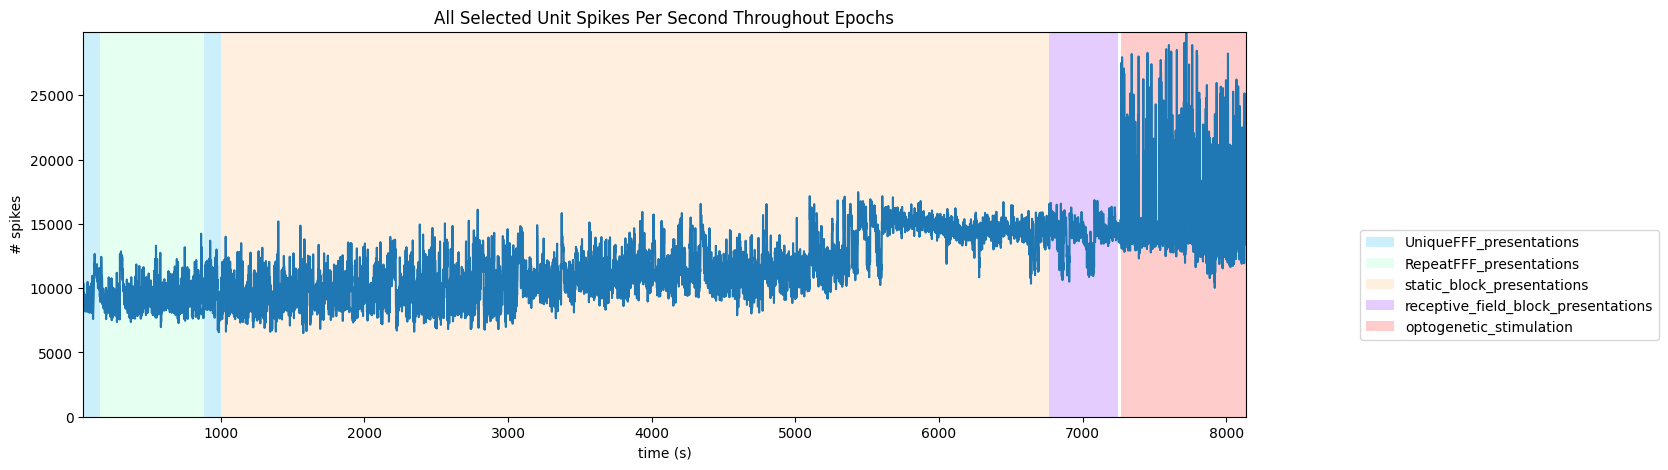

In [ ]:
# generate plot of spike histogram with colored epoch intervals and legend
fig, ax = plt.subplots(figsize=(15,5))

# assign unique color to each stimulus name
stim_names = list({epoch[0] for epoch in epochs})
colors = plt.cm.rainbow(np.linspace(0,1,len(stim_names)))
stim_color_map = {stim_names[i]:colors[i] for i in range(len(stim_names))}

epoch_key = {}
height = max(hist)
# draw colored rectangles for each epoch
for epoch in epochs:
    stim_name, stim_block, epoch_start, epoch_end = epoch
    color = stim_color_map[stim_name]
    rec = ax.add_patch(mpl.patches.Rectangle((epoch_start, 0), epoch_end-epoch_start, height, alpha=0.2, facecolor=color))
    epoch_key[stim_name] = rec

ax.set_xlim(time_start, time_end)
ax.set_ylim(-0.1, height+0.1)
ax.set_xlabel("time (s)")
ax.set_ylabel("# spikes")
ax.set_title("All Selected Unit Spikes Per Second Throughout Epochs")

fig.legend(epoch_key.values(), epoch_key.keys(), loc="lower right", bbox_to_anchor=(1.18, 0.25))
ax.plot(bins[:-1], hist)

In [49]:
# Encoding model example 1: recover stimulus-specific interaction terms with a Poisson GLM
import numpy as np
import pandas as pd
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_poisson_deviance

rng = np.random.default_rng(0)
n_bins_syn = 2500

stimulus_id = rng.integers(0, 3, size=n_bins_syn)  # 3 stimulus classes
contrast = rng.uniform(0.2, 1.0, size=n_bins_syn)
history_short = rng.poisson(0.4, size=n_bins_syn)
history_long = rng.poisson(1.0, size=n_bins_syn)

stim_1 = (stimulus_id == 1).astype(float)
stim_2 = (stimulus_id == 2).astype(float)

X_syn = np.column_stack([
    contrast,
    history_short,
    history_long,
    stim_1,
    stim_2,
    stim_1 * history_short,
    stim_2 * history_short,
])
feature_names_syn = [
    "contrast",
    "history_short",
    "history_long",
    "stim_1",
    "stim_2",
    "stim_1_x_history_short",
    "stim_2_x_history_short",
]

beta_true = np.array([0.8, 0.35, -0.15, 0.5, -0.4, 0.65, -0.55])
log_rate = -1.3 + X_syn @ beta_true
rate_syn = np.exp(log_rate)
y_syn = rng.poisson(rate_syn)

glm_syn = PoissonRegressor(alpha=1e-4, max_iter=4000)
glm_syn.fit(X_syn, y_syn)

coef_table_syn = pd.DataFrame({
    "feature": feature_names_syn,
    "true_beta": beta_true,
    "fitted_beta": glm_syn.coef_,
})
coef_table_syn["abs_error"] = np.abs(coef_table_syn["fitted_beta"] - coef_table_syn["true_beta"])

cv = KFold(n_splits=5, shuffle=True, random_state=0)
cv_deviance = []
for tr_idx, te_idx in cv.split(X_syn):
    glm_cv = PoissonRegressor(alpha=1e-4, max_iter=4000)
    glm_cv.fit(X_syn[tr_idx], y_syn[tr_idx])
    yhat = glm_cv.predict(X_syn[te_idx])
    cv_deviance.append(mean_poisson_deviance(y_syn[te_idx], np.clip(yhat, 1e-9, None)))

print("Synthetic GLM example (known ground truth)")
print("Mean CV Poisson deviance:", round(float(np.mean(cv_deviance)), 4))
print("Lower deviance indicates better out-of-sample fit.")
print("\nRecovered interaction terms:")
display(coef_table_syn[coef_table_syn["feature"].str.contains("_x_")].round(3))
print("\nAll coefficients:")
display(coef_table_syn.round(3))

Synthetic GLM example (known ground truth)
Mean CV Poisson deviance: 0.9227
Lower deviance indicates better out-of-sample fit.

Recovered interaction terms:


,feature,true_beta,fitted_beta,abs_error
5,stim_1_x_history_short,0.65,0.566,0.084
6,stim_2_x_history_short,-0.55,-0.587,0.037



All coefficients:


,feature,true_beta,fitted_beta,abs_error
0,contrast,0.80,0.867,0.067
1,history_short,0.35,0.392,0.042
2,history_long,-0.15,-0.160,0.010
3,stim_1,0.50,0.480,0.020
4,stim_2,-0.40,-0.395,0.005
5,stim_1_x_history_short,0.65,0.566,0.084
6,stim_2_x_history_short,-0.55,-0.587,0.037


Missing ['epochs']; building a synthetic session-like example for demonstration.
Session GLM (unit index = 0, bin_size = 0.050s)
Pseudo-R^2 vs intercept-only model: -0.0351

Top stimulus-history interaction effects:


,feature,beta,abs_beta
5,stim_stim_B_x_history_1,-0.0218,0.0218
6,stim_stim_C_x_history_1,-0.0003,0.0003



Top overall effects:


,feature,beta,abs_beta
3,stim_stim_B,0.7079,0.7079
4,stim_stim_C,0.0253,0.0253
5,stim_stim_B_x_history_1,-0.0218,0.0218
1,history_2to4,0.0131,0.0131
2,time_norm,-0.0115,0.0115
6,stim_stim_C_x_history_1,-0.0003,0.0003
0,history_1,0.0000,0.0000


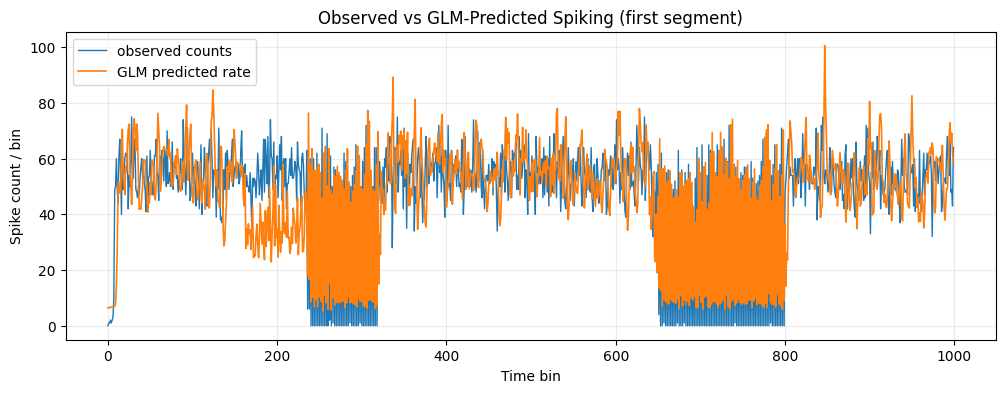

In [50]:
# Encoding model example 2: fit a stimulus-aware GLM on session data (with synthetic fallback)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import PoissonRegressor

required = ["epochs", "units_spike_times"]
missing = [name for name in required if name not in globals()]

if missing:
    print(f"Missing {missing}; building a synthetic session-like example for demonstration.")
    rng_local = np.random.default_rng(1)

    synthetic_epochs = []
    t = 0.0
    labels = ["stim_A", "stim_B", "stim_C"]
    for i in range(36):
        duration = 8.0
        label = labels[i % len(labels)]
        synthetic_epochs.append((label, float(i % 3), t, t + duration))
        t += duration

    bin_size = 0.05
    session_start = 0.0
    session_stop = t
    bin_edges = np.arange(session_start, session_stop + bin_size, bin_size)
    bin_centers = bin_edges[:-1] + 0.5 * bin_size

    stim_per_bin = np.array(["none"] * len(bin_centers), dtype=object)
    for stim_name, stim_block, t0, t1 in synthetic_epochs:
        mask = (bin_centers >= float(t0)) & (bin_centers < float(t1))
        stim_per_bin[mask] = str(stim_name)

    # Generate synthetic counts from known stimulus + history interactions.
    y_counts = np.zeros(len(bin_centers), dtype=int)
    for i in range(len(y_counts)):
        s = stim_per_bin[i]
        h1 = y_counts[i - 1] if i - 1 >= 0 else 0
        h2to4 = y_counts[max(0, i - 4):max(0, i - 1)].sum()
        stim_A = 1.0 if s == "stim_A" else 0.0
        stim_B = 1.0 if s == "stim_B" else 0.0
        log_rate_i = -1.4 + 0.35 * h1 + 0.08 * h2to4 + 0.55 * stim_A - 0.35 * stim_B + 0.6 * stim_A * h1 - 0.45 * stim_B * h1
        rate_i = np.exp(np.clip(log_rate_i, -6, 4))
        y_counts[i] = rng_local.poisson(rate_i)

    target_unit = 0
else:
    bin_size = 0.05  # 50 ms bins
    session_start = float(min(epoch[2] for epoch in epochs))
    session_stop = float(max(epoch[3] for epoch in epochs))
    bin_edges = np.arange(session_start, session_stop + bin_size, bin_size)
    if len(bin_edges) < 10:
        raise ValueError("Not enough bins to fit a GLM. Check epoch extraction.")

    bin_centers = bin_edges[:-1] + 0.5 * bin_size
    stim_per_bin = np.array(["none"] * len(bin_centers), dtype=object)
    for stim_name, stim_block, t0, t1 in epochs:
        mask = (bin_centers >= float(t0)) & (bin_centers < float(t1))
        stim_per_bin[mask] = str(stim_name)

    if "goodUnits" in globals() and len(goodUnits) > 0:
        target_unit = int(goodUnits[0])
    else:
        target_unit = 0
    if target_unit >= len(units_spike_times):
        target_unit = 0

    unit_spikes = np.asarray(units_spike_times[target_unit], dtype=float)
    y_counts, _ = np.histogram(unit_spikes, bins=bin_edges)
    if np.all(y_counts == 0):
        raise ValueError("Selected unit has no spikes in analyzed epochs. Pick a different unit.")

# Temporal barcode history features (past-only terms)
history_1 = np.zeros_like(y_counts, dtype=float)
history_1[1:] = y_counts[:-1]

history_2to4 = np.zeros_like(y_counts, dtype=float)
for lag in (2, 3, 4):
    history_2to4[lag:] += y_counts[:-lag]

time_norm = (bin_centers - np.mean(bin_centers)) / (np.std(bin_centers) + 1e-9)
stim_dummies = pd.get_dummies(stim_per_bin, prefix="stim", drop_first=True, dtype=float)

X_df = pd.DataFrame({
    "history_1": history_1,
    "history_2to4": history_2to4,
    "time_norm": time_norm,
})
X_df = pd.concat([X_df.reset_index(drop=True), stim_dummies.reset_index(drop=True)], axis=1)

# Interaction terms: does short-history effect change by stimulus?
for col in stim_dummies.columns:
    X_df[f"{col}_x_history_1"] = stim_dummies[col].to_numpy() * history_1

glm_real = PoissonRegressor(alpha=1e-3, max_iter=4000)
glm_real.fit(X_df, y_counts)
yhat_real = np.clip(glm_real.predict(X_df), 1e-9, None)

mu_null = np.clip(np.mean(y_counts), 1e-9, None)
ll_model = float(np.sum(y_counts * np.log(yhat_real) - yhat_real))
ll_null = float(np.sum(y_counts * np.log(mu_null) - mu_null))
pseudo_r2 = np.nan if ll_null == 0 else 1.0 - (ll_model / ll_null)

coef_real = pd.DataFrame({
    "feature": X_df.columns,
    "beta": glm_real.coef_,
})
coef_real["abs_beta"] = np.abs(coef_real["beta"])
coef_real = coef_real.sort_values("abs_beta", ascending=False)

interaction_effects = coef_real[coef_real["feature"].str.contains("_x_history_1")]

print(f"Session GLM (unit index = {target_unit}, bin_size = {bin_size:.3f}s)")
print("Pseudo-R^2 vs intercept-only model:", round(float(pseudo_r2), 4))
print("\nTop stimulus-history interaction effects:")
display(interaction_effects.head(10).round(4))
print("\nTop overall effects:")
display(coef_real.head(15).round(4))

plt.figure(figsize=(12, 4))
plot_n = min(1000, len(y_counts))
plt.plot(y_counts[:plot_n], label="observed counts", linewidth=1.0)
plt.plot(yhat_real[:plot_n], label="GLM predicted rate", linewidth=1.2)
plt.xlabel("Time bin")
plt.ylabel("Spike count / bin")
plt.title("Observed vs GLM-Predicted Spiking (first segment)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()